# Indexes BID (2021)

Este notebook crea los indicadores BID relacionados con usos de suelo e indicadores socio económicos.

In [1]:
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == 'src' else cwd
DATA_DIR = root / 'data'
MULTI_DIR = DATA_DIR / 'multiproposito'
EXPORT_DIR = DATA_DIR / 'export'

sys.path.append(str(root / 'src'))
from soil_poverty_analysis import (
    find_repo_root,
    parse_weight_series,
    normalize_municipality,
    export_excel,
    gini_coefficient,
)

In [2]:
manual_mapping = {
    'bojaca': 'Bojacá',
    'cajica': 'Cajicá',
    'chia': 'Chía',
    'cota': 'Cota',
    'facatativa': 'Facatativá',
    'funza': 'Funza',
    'gachancipa': 'Gachancipá',
    'sibate': 'Sibaté',
    'sopo': 'Sopó',
    'tocancipa': 'Tocancipá',
    'zipacon': 'Zipacón',
    'zipaquira': 'Zipaquirá',
    'el rosal': 'El Rosal',
    'la calera': 'La Calera',
    'madrid': 'Madrid',
    'mosquera': 'Mosquera',
    'subachoque': 'Subachoque',
    'tabio': 'Tabio',
    'tenjo': 'Tenjo',
    'soacha': 'Soacha',
}

municipios_order_excel = ['El Rosal', 'Facatativá', 'Subachoque', 
                          'Bojacá', 'Funza', 'Madrid', 'Mosquera', 'Zipacón', 
                          'Gachancipá', 'Tocancipá', 'Zipaquirá',
                          'Cajicá', 'Chía', 'Cota', 'Sopó', 'Tabio', 'Tenjo',
                          'La Calera',
                          'Sibaté', 'Soacha'
                          ]

In [3]:
# order compatible with excel export file
municipios_order_df = pd.DataFrame(municipios_order_excel, columns=['municipio'])

In [4]:
# Funciones auxiliares (copiadas del notebook 30_transicion_pobreza_dispersion_adj.ipynb)
def load_semicolon_csv(path, columns=None, encodings=('utf-8', 'latin1')):
    last_error = None
    for encoding in encodings:
        try:
            if columns is None:
                return pd.read_csv(path, sep=';', encoding=encoding)
            return pd.read_csv(path, sep=';', encoding=encoding, usecols=list(columns))
        except Exception as exc:
            last_error = exc
    raise last_error

def load_transition(path):
    df = pd.read_csv(path, sep=',')
    df.columns = ['from_class', 'to_class', 'area_ha']
    df['area_ha'] = pd.to_numeric(df['area_ha'], errors='coerce')
    return df

def compute_transition_indices(path, municipio_base):
    df = load_transition(path)
    total = df['area_ha'].sum()
    f = df.set_index(['from_class', 'to_class'])['area_ha'].to_dict()
    get = lambda a, b: f.get((a, b), 0.0)
    F_ForAgro = get('Forest formation', 'Agricultural and livestock area')
    F_WatAgro = get('Water body', 'Agricultural and livestock area')
    F_AgroFor = get('Agricultural and livestock area', 'Forest formation')
    F_AgroWat = get('Agricultural and livestock area', 'Water body')
    F_ForFor = get('Forest formation', 'Forest formation')
    F_WatWat = get('Water body', 'Water body')
    F_AgroAgro = get('Agricultural and livestock area', 'Agricultural and livestock area')
    A_total = total
    degrad_total = (F_ForAgro + F_WatAgro) / A_total * 100 if A_total else np.nan
    recover_total = (F_AgroFor + F_AgroWat) / A_total * 100 if A_total else np.nan
    degrad_forest_rel = F_ForAgro / F_ForFor if F_ForFor else np.nan
    degrad_water_rel = F_WatAgro / F_WatWat if F_WatWat else np.nan
    recover_agro_rel = F_AgroFor / F_AgroAgro if F_AgroAgro else np.nan
    ind_neto_transicion = degrad_total - recover_total
    ind_neto_transicion_rel = (degrad_forest_rel + degrad_water_rel) - recover_agro_rel
    return {
        'municipio_base': municipio_base,
        'A_total': A_total,
        'F_ForAgro': F_ForAgro,
        'F_WatAgro': F_WatAgro,
        'F_AgroFor': F_AgroFor,
        'F_AgroWat': F_AgroWat,
        'F_ForFor': F_ForFor,
        'F_WatWat': F_WatWat,
        'F_AgroAgro': F_AgroAgro,
        'degrad_total': degrad_total,
        'recover_total': recover_total,
        'degrad_forest_rel': degrad_forest_rel,
        'degrad_water_rel': degrad_water_rel,
        'recover_agro_rel': recover_agro_rel,
        'ind_neto_transicion': ind_neto_transicion,
        'ind_neto_transicion_rel': ind_neto_transicion_rel,
    }


In [5]:
def plot_stacked_bars_raw_weighted(df, var, title, weight_col='weight', order_by_freq=True):
    """Plot stacked bar chart for a raw categorical variable with weights."""
    # Weighted crosstab
    df_valid = df.dropna(subset=[var, weight_col, 'municipio_base']).copy()
    
    # Calculate weighted percentages per municipality and category
    weighted_counts = df_valid.groupby(['municipio_base', var])[weight_col].sum().unstack(fill_value=0)
    weighted_pct = weighted_counts.div(weighted_counts.sum(axis=1), axis=0) * 100
    
    if order_by_freq:
        # Order categories by overall weighted frequency
        cat_weights = df_valid.groupby(var)[weight_col].sum().sort_values(ascending=False)
        cat_order = cat_weights.index.tolist()
        weighted_pct = weighted_pct.reindex(columns=cat_order, fill_value=0)
    
    # Order municipalities by the lowest category weighted percentage (ascending, from 0 onwards)
    if len(weighted_pct.columns) > 0:
        first_cat = weighted_pct.columns[0]
        muni_order = weighted_pct.sort_values(first_cat, ascending=True).index.tolist()
        weighted_pct = weighted_pct.loc[muni_order]

    print(raw_var_questions.get(var, "Question not found"))
    print(raw_var_options.get(var, "Options not found"))
    
    ax = weighted_pct.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
    plt.title(f'{title} ({var}) - Weighted (FEX_C)', fontsize=14)
    plt.xlabel('Municipio', fontsize=12)
    plt.ylabel('Porcentaje ponderado (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_stacked_bars_bin_weighted(df, var, title, weight_col='weight', order_by_freq=True):
    """Plot stacked bar chart for a binarized variable (0 vs 1) with weights."""
    df_valid = df.dropna(subset=[var, weight_col, 'municipio_base']).copy()
    
    # Weighted percentages
    weighted_counts = df_valid.groupby(['municipio_base', var])[weight_col].sum().unstack(fill_value=0)
    weighted_pct = weighted_counts.div(weighted_counts.sum(axis=1), axis=0) * 100
    
    # Ensure both 0 and 1 columns exist
    for cat in [0, 1]:
        if cat not in weighted_pct.columns:
            weighted_pct[cat] = 0
    weighted_pct = weighted_pct[[0, 1]]  # Order: 0 first, then 1
    
    if order_by_freq:
        # Order municipalities by frequency of 1 (ascending)
        muni_order = weighted_pct.sort_values(1, ascending=True).index.tolist()
        weighted_pct = weighted_pct.loc[muni_order]

    ax = weighted_pct.plot(kind='bar', stacked=True, figsize=(14, 6), color=['#ff7f7f', '#7fff7f'])
    plt.title(f'{title} ({var}) - Weighted (FEX_C)', fontsize=14)
    plt.xlabel('Municipio', fontsize=12)
    plt.ylabel('Porcentaje ponderado (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(['No (0)', 'Sí (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # print(f"\n{title} ({var}) - Weighted percentage by municipality:")
    # print(weighted_pct.round(1))
    # print()

    return weighted_pct

## Variables adicionales

In [6]:
print('Reading the Excel file...')
df = pd.read_excel('/home/wilomaku/Code/maps-social-Colombia/data/20240430_variables_adicionales_2021.xlsx', header=None)

print(f'Shape: {df.shape}')
print('\\nFirst row (raw variable names):')
first_row = df.iloc[0]
print(first_row.values[0])

# Extract comma-separated values from the first row
var_names = str(first_row.values[0]).split(',')
print(f'\\nNumber of variables: {len(var_names)}')
print('Variable names:', var_names)

# Process all rows
data_rows = []
for idx, row in df.iloc[1:].iterrows():
    row_values = str(row[0]).split(',')
    data_rows.append(row_values)

# Create DataFrame
additional_df = pd.DataFrame(data_rows, columns=var_names)

print(f'\\nFinal DataFrame shape: {additional_df.shape}')
print('\\nFirst 5 rows:')
print(additional_df.head())

# Check data types and basic info
print('\\nDataFrame info:')
print(additional_df.dtypes.value_counts())

# Quick validation - count null values
print('\\nNull values count per column (first 10):')
null_counts = additional_df.isnull().sum().head(10)
for col, count in null_counts.items():
    if count > 0:
        print(f'{col}: {count}')

print('\\nParsing complete!')

Reading the Excel file...
Shape: (292282, 1)
\nFirst row (raw variable names):
directorio_hog,directorio_per,directorio,N_tipo_vivienda,N_deficit_paredes,N_cohabitacion,N_hacinamiento_critico,N_deficit_cuantitativo,N_hacinamiento_mitigable,N_deficit_pisos,N_deficit_cocina,N_deficit_agua,N_alcantarillado,N_energia,N_deficit_recoleccion,N_hacinamientomit_jer,N_pisos_jer,N_cocina_jer,N_agua_jer,N_alcantarillado_jer,N_energia_jer,N_recoleccion_jer,N_deficit_cualitativo,N_deficit_habitacional,N_PET,N_fuerza_trabajo,N_ocupados,N_desocupados,N_fuera_fuerza_trabajo,N_informal,N_bajo_logro,N_analfabeta,N_inasistencia,N_rezago,N_atencion,N_trabajo_infantil,N_desempleo_ld,N_empleo_informal,N_salud,N_acceso_salud,N_acceso_agua,N_excretas,N_pisos,N_paredes,N_hacinamiento,N_pobre_ipm,N_codigo_upz_trabajo,N_codigo_localidad_trabajo,N_INGTOT_PER,N_NUG,N_INGTOTUG_PER,N_IMPAES_,N_ISAES_,N_IEES_,N_IMDIES_,N_IOF2ES_,N_IOF3ES_,N_IOF6ES_,N_ingtot,N_ingpc,N_ingtotug,N_ingpcug,N_ingtotugarr,N_ingpcugarr,N_lp3

In [7]:
additional_df = additional_df[['directorio_hog', 'directorio_per', 'directorio', 
                               'N_pobre_monetario', 'N_pobre_extremo', 'N_pobre_ipm', 'N_ingpc', 'N_informal', 'N_deficit_cualitativo', 'N_deficit_cuantitativo',
                               'N_ocupados', 'N_desocupados',
                               ]]

additional_df = additional_df.rename(columns={
    'directorio_hog': 'DIRECTORIO_HOG',
    'directorio_per': 'DIRECTORIO_PER',
    'directorio': 'DIRECTORIO',
})

In [8]:
# Load raw data
ident = load_semicolon_csv(
    MULTI_DIR / 'Identificación (Capítulo A).csv',
    columns=['DIRECTORIO', 'DPTO', 'MPIO', 'NOMBRE_ESTRATO', 'FEX_C'],
    encodings=('latin1', 'utf-8'),
)
ident['weight'] = parse_weight_series(ident['FEX_C'])
ident_cund = ident[ident['DPTO'] == 25].copy()

households_e = load_semicolon_csv(
    MULTI_DIR / 'Composición del hogar y demografía (Capítulo E).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'DIRECTORIO_PER', 'FEX_C'],
)

In [9]:
base_households = ident_cund[['DIRECTORIO', 'NOMBRE_ESTRATO']].copy()
households_e = households_e.merge(base_households, on='DIRECTORIO', how='inner')

households_e['weight'] = parse_weight_series(households_e['FEX_C'])
households_e.drop(columns=['FEX_C'], inplace=True)

In [10]:
# Get list of 21 municipalities
ident_unique = ident_cund[['NOMBRE_ESTRATO']].drop_duplicates().copy()
ident_unique['municipio_base'] = ident_unique['NOMBRE_ESTRATO'].apply(normalize_municipality)
ident_unique['municipio_base'] = ident_unique['municipio_base'].map(lambda x: manual_mapping.get(x, x))
municipios_21 = ident_unique['municipio_base'].unique()

municipios_20 = [municipio for municipio in municipios_21 if municipio != 'fusagasuga']
print(f'Municipios considerados:\n {municipios_20}')

Municipios considerados:
 ['Sibaté', 'Mosquera', 'Cota', 'Chía', 'Sopó', 'Tabio', 'Zipacón', 'Soacha', 'Cajicá', 'Tocancipá', 'Madrid', 'Funza', 'El Rosal', 'Bojacá', 'Tenjo', 'Zipaquirá', 'Facatativá', 'Subachoque', 'La Calera', 'Gachancipá']


In [11]:
# Filter to 21 municipalities
households_e['municipio_base'] = households_e['NOMBRE_ESTRATO'].apply(normalize_municipality).map(lambda x: manual_mapping.get(x, x))
households = households_e[households_e['municipio_base'].isin(municipios_20)].copy()

# Create households_raw from households (already has all raw variables)
households_raw = households.copy()

In [12]:
# cast columns to numeric types
additional_df['N_informal'] = pd.to_numeric(additional_df['N_informal'], errors='coerce')
additional_df['N_ingpc'] = pd.to_numeric(additional_df['N_ingpc'], errors='coerce')
additional_df['N_ocupados'] = pd.to_numeric(additional_df['N_ocupados'], errors='coerce')
additional_df['N_desocupados'] = pd.to_numeric(additional_df['N_desocupados'], errors='coerce')

additional_df = additional_df.astype({'DIRECTORIO_HOG': 'int64', 
                                      'DIRECTORIO': 'int64', 
                                      'DIRECTORIO_PER': 'int64',
                                      'N_pobre_monetario': 'int64', 
                                      'N_pobre_extremo': 'int64', 
                                      'N_pobre_ipm': 'int64',
                                    #   'N_ingpc': 'float', 
                                    #   'N_informal': 'int64',
                                    #   'N_ocupados': 'int64',
                                    #   'N_desocupados': 'int64',
                                      'N_deficit_cualitativo': 'int64', 
                                      'N_deficit_cuantitativo': 'int64',
                                      })
additional_df

,DIRECTORIO_HOG,DIRECTORIO_PER,DIRECTORIO,N_pobre_monetario,N_pobre_extremo,N_pobre_ipm,N_ingpc,N_informal,N_deficit_cualitativo,N_deficit_cuantitativo,N_ocupados,N_desocupados
0,1662381,16623812,166238,0,0,1,2.083333e+05,NaN,1,0,0.0,0.0
1,1662381,16623811,166238,0,0,1,2.083333e+05,NaN,1,0,0.0,0.0
2,2201021,22010213,220102,0,0,0,2.750000e+05,NaN,0,0,0.0,0.0
3,2201021,22010212,220102,0,0,0,2.750000e+05,NaN,0,0,0.0,0.0
4,2201021,22010214,220102,0,0,0,2.750000e+05,NaN,0,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
292276,30068111,300681113,3006811,0,0,0,1.248333e+06,1.0,0,0,1.0,0.0
292277,30068111,300681112,3006811,0,0,0,1.248333e+06,NaN,0,0,0.0,0.0
292278,30068121,300681212,3006812,0,0,0,6.166667e+05,NaN,0,0,0.0,1.0
292279,30068121,300681213,3006812,0,0,0,6.166667e+05,NaN,0,0,0.0,1.0


In [13]:
additional_df = households.merge(additional_df, on=['DIRECTORIO_HOG', 'DIRECTORIO', 'DIRECTORIO_PER'], how='inner')
additional_df.shape

(54917, 15)

In [14]:
additional_df['weight'] = pd.to_numeric(additional_df['weight'], errors='coerce')

In [15]:
additional_df[['N_pobre_monetario', 'N_pobre_extremo', 'N_pobre_ipm', 'N_ingpc', 'N_informal', 'N_deficit_cualitativo', 'N_deficit_cuantitativo',]].describe()

,N_pobre_monetario,N_pobre_extremo,N_pobre_ipm,N_ingpc,N_informal,N_deficit_cualitativo,N_deficit_cuantitativo
count,54917.000000,54917.000000,54917.000000,5.343600e+04,25123.000000,54917.000000,54917.000000
mean,0.172078,0.060819,0.063842,8.869142e+05,0.417227,0.164284,0.019265
std,0.377452,0.239000,0.244473,1.357423e+06,0.493111,0.370537,0.137458
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,3.508889e+05,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,5.739435e+05,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,9.462667e+05,1.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,5.300000e+07,1.000000,1.000000,1.000000


### Data engineering (ingpc)

In [16]:
additional_df[['DIRECTORIO', 'N_ingpc', 'N_informal', 'N_ocupados', 'N_desocupados']].describe()

,DIRECTORIO,N_ingpc,N_informal,N_ocupados,N_desocupados
count,5.491700e+04,5.343600e+04,25123.000000,43910.000000,43910.000000
mean,1.071468e+06,8.869142e+05,0.417227,0.571852,0.064131
std,3.593554e+05,1.357423e+06,0.493111,0.494816,0.244989
min,3.231660e+05,0.000000e+00,0.000000,0.000000,0.000000
25%,1.013620e+06,3.508889e+05,0.000000,0.000000,0.000000
50%,1.051157e+06,5.739435e+05,0.000000,1.000000,0.000000
75%,1.144144e+06,9.462667e+05,1.000000,1.000000,0.000000
max,2.193139e+06,5.300000e+07,1.000000,1.000000,1.000000


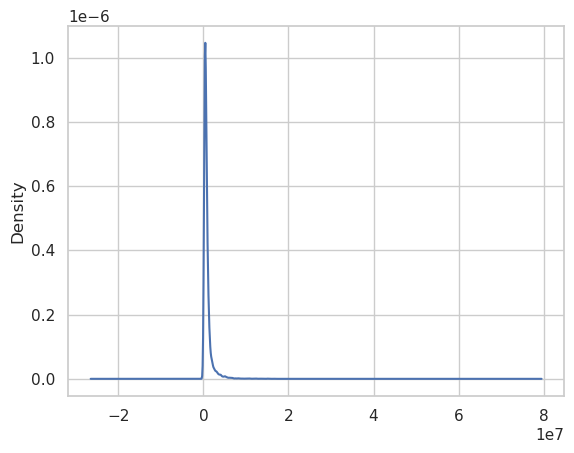

In [17]:
# Plot N_ingpc distribution
additional_df['N_ingpc'].plot(kind='kde')
plt.show()

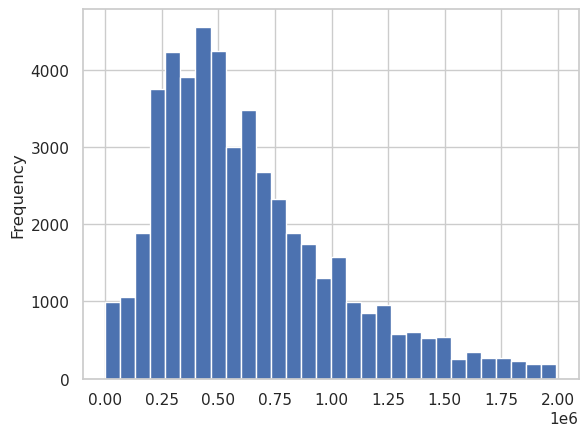

In [18]:
# Plot N_ingpc distribution
additional_df[additional_df['N_ingpc']<2000000]['N_ingpc'].plot(kind='hist', bins=30)
plt.show()

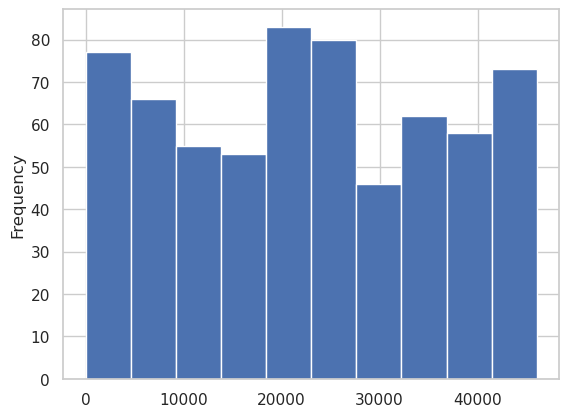

In [19]:
min_threshold_ingpc = 50000

# Plot N_ingpc distribution
additional_df[additional_df['N_ingpc']<min_threshold_ingpc]['N_ingpc'].plot(kind='hist')
plt.show()

In [20]:
# transform additional_df['N_ingpc'] in log
additional_df['bin_N_ingpc'] = additional_df['N_ingpc'] > min_threshold_ingpc
additional_df.loc[additional_df['N_ingpc'].isnull(), 'bin_N_ingpc'] = np.nan   
additional_df['bin_N_ingpc'].value_counts(normalize=True, dropna=False)
# additional_df['N_ingpc'].value_counts(normalize=True, dropna=False)

bin_N_ingpc
True     0.958829
NaN      0.026968
False    0.014203
Name: proportion, dtype: float64

In [21]:
# Percentage distribution of N_informal by municipio_base
(pd.crosstab(additional_df['N_ocupados'].fillna(-1), additional_df['bin_N_ingpc'].fillna(-1))
    .mul(100)
    .round(2))

bin_N_ingpc,-1,False,True
N_ocupados,,,
-1.0,24400,13600,1062700
0.0,123700,53800,1702500
1.0,0,10600,2500400


In [22]:
additional_df.fillna(-1).groupby('N_ocupados').agg({'N_ingpc': ['count', 'min', 'median', 'max']})

N_ingpc                                
             count  min         median         max
N_ocupados                                        
-1.0         11007 -1.0  425000.000000  23250000.0
 0.0         18800 -1.0  471897.666667  40000000.0
 1.0         25110  0.0  700000.000000  53000000.0

In [68]:
additional_df.groupby('N_pobre_monetario').agg({'N_ingpc': ['mean', 'median']})

N_ingpc          
                           mean    median
N_pobre_monetario                        
0                  1.008032e+06  651709.2
1                  1.958788e+05  201500.0

### GINI Coeficient calculation

In [23]:
# Weighted GINI coefficient for N_ingpc (income per capita)
gini_df = additional_df.dropna(subset=['N_ingpc', 'weight']).copy()

overall_gini = gini_coefficient(gini_df['N_ingpc'], gini_df['weight'])
print(f'Overall weighted GINI coefficient for N_ingpc: {overall_gini:.4f}')

# Compute GINI per municipality
gini_by_muni = []
for muni, group in gini_df.groupby('municipio_base'):
    g = gini_coefficient(group['N_ingpc'], group['weight'])
    n = len(group)
    gini_by_muni.append({'municipio_base': muni, 'gini_N_ingpc': g, 'n_observations': n})

gini_muni_df = pd.DataFrame(gini_by_muni).sort_values('gini_N_ingpc', ascending=False)
gini_muni_df = gini_muni_df.rename(columns={'municipio_base': 'municipio'})

Overall weighted GINI coefficient for N_ingpc: 0.4597


In [24]:
# Merge with ordered municipality list
gini_muni_df = municipios_order_df.merge(gini_muni_df, on='municipio', how='left')

gini_muni_df

,municipio,gini_N_ingpc,n_observations
0,El Rosal,0.329156,2054
1,Facatativá,0.462307,2435
2,Subachoque,0.425502,1795
3,Bojacá,0.418878,1662
4,Funza,0.435996,3897
5,Madrid,0.508015,2359
6,Mosquera,0.423102,3783
7,Zipacón,0.399153,1026
8,Gachancipá,0.335472,1846
9,Tocancipá,0.383084,1996


In [25]:
save_path = EXPORT_DIR / 'GINI_2021.csv'
export_excel(gini_muni_df[['municipio', 'gini_N_ingpc']], save_path)

succesfully saved, check export folder


### Data engineering (informal)

In [26]:
additional_df['N_informal'].value_counts(normalize=True, dropna=False)

N_informal
NaN    0.542528
0.0    0.266602
1.0    0.190870
Name: proportion, dtype: float64

In [27]:
# Percentage distribution of N_informal by municipio_base
(pd.crosstab(additional_df['municipio_base'], additional_df['N_informal'].fillna(-1), normalize='index')
    .mul(100)
    .round(2))

N_informal,-1.0,0.0,1.0
municipio_base,,,
Bojacá,58.10,24.57,17.33
Cajicá,54.87,26.63,18.50
Chía,52.68,24.60,22.72
Cota,52.54,26.13,21.33
El Rosal,55.19,32.99,11.82
Facatativá,57.72,30.06,12.22
Funza,53.08,25.86,21.06
Gachancipá,55.10,31.55,13.36
La Calera,53.15,22.79,24.06


In [28]:
# Percentage distribution of N_informal by municipio_base
(pd.crosstab(additional_df['N_ocupados'].fillna(-1), additional_df['N_desocupados'].fillna(-1), normalize='index')
    .mul(100)
    .round(2))

N_desocupados,-1.0,0.0,1.0
N_ocupados,,,
-1.0,100.0,0.00,0.00
0.0,0.0,85.02,14.98
1.0,0.0,100.00,0.00


In [29]:
# Percentage distribution of N_informal by municipio_base
(pd.crosstab(additional_df['N_ocupados'].fillna(-1), additional_df['N_informal'].fillna(-1), normalize='index')
    .mul(100)
    .round(2))

N_informal,-1.0,0.0,1.0
N_ocupados,,,
-1.0,99.88,0.05,0.07
0.0,100.00,0.00,0.00
1.0,0.00,58.29,41.71


### Bar plots categorical vars

In [30]:
# Create binarized variables per summary_dict.md
additional_df['bin_pobre_monetario'] = (additional_df['N_pobre_monetario']).astype(float)
additional_df['bin_pobre_extremo'] = (additional_df['N_pobre_extremo']).astype(float)
additional_df['bin_pobre_ipm'] = (additional_df['N_pobre_ipm']).astype(float)
additional_df['bin_informal'] = (additional_df['N_informal']).astype(float)
additional_df['bin_deficit_cualitativo'] = (additional_df['N_deficit_cualitativo']).astype(float)
additional_df['bin_deficit_cuantitativo'] = (additional_df['N_deficit_cuantitativo']).astype(float)

In [31]:
# numérica 'N_ingpc'
# Raw categorical variables from summary_dict.md
raw_vars = {
    'N_pobre_monetario': 'Porcentaje de la población por debajo de la línea de pobreza',
    'N_pobre_extremo': 'Porcentaje de la población por debajo de la línea de pobreza',
    'N_pobre_ipm': 'Porcentaje de viviendas con pobreza multidimensional',
    'N_informal': 'Ocupados informales',
    'N_deficit_cualitativo': 'Porcentaje de unidades de vivienda en condiciones inferiores a los estándares de habitabilidad',
    'N_deficit_cuantitativo': 'Porcentaje de cantidad de hogares en déficit cuantitativo',
}

binary_vars = {
    'bin_pobre_monetario': 'Porcentaje de la población por debajo de la línea de pobreza',
    'bin_pobre_extremo': 'Porcentaje de la población por debajo de la línea de pobreza',
    'bin_pobre_ipm': 'Porcentaje de viviendas con pobreza multidimensional',
    'bin_informal': 'Ocupados informales',
    'bin_deficit_cualitativo': 'Porcentaje de unidades de vivienda en condiciones inferiores a los estándares de habitabilidad',
    'bin_deficit_cuantitativo': 'Porcentaje de cantidad de hogares en déficit cuantitativo',
}

# Detailed categorical values from summary_dict.md
raw_var_questions = {
    'N_pobre_monetario': 'Porcentaje de la población por debajo de la línea de pobreza',
    'N_pobre_extremo': 'Porcentaje de la población por debajo de la línea de pobreza',
    'N_pobre_ipm': 'Porcentaje de viviendas con pobreza multidimensional',
    'N_informal': 'Ocupados informales',
    'N_deficit_cualitativo': 'Porcentaje de unidades de vivienda en condiciones inferiores a los estándares de habitabilidad',
    'N_deficit_cuantitativo': 'Porcentaje de cantidad de hogares en déficit cuantitativo',
}

# Detailed categorical values from summary_dict.md
raw_var_options = {
    'N_pobre_monetario': "1: 'Si'\n0: 'No'",
    'N_pobre_extremo': "1: 'Si'\n0: 'No'",
    'N_pobre_ipm': "1: 'Si'\n0: 'No'",
    'N_informal': "1: 'Informal'\n0: 'Formal'",
    'N_deficit_cualitativo': "1: 'Si'\n0: 'No'",
    'N_deficit_cuantitativo': "1: 'Si'\n0: 'No'",
}

Porcentaje de la población por debajo de la línea de pobreza
1: 'Si'
0: 'No'


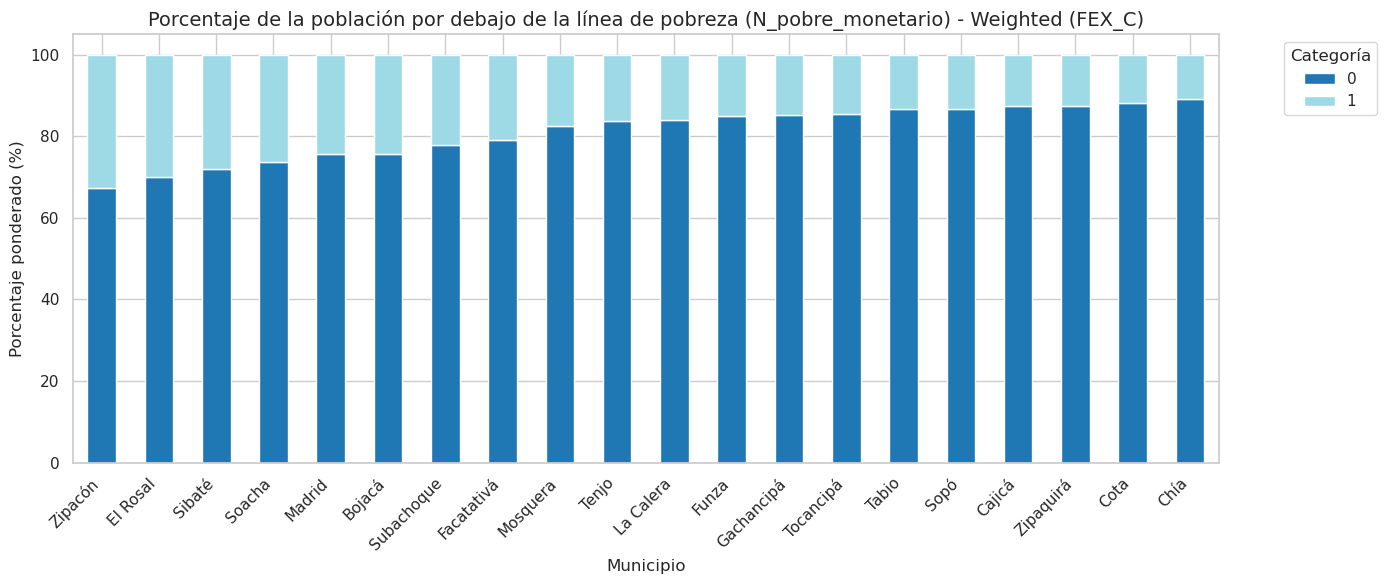

Porcentaje de la población por debajo de la línea de pobreza
1: 'Si'
0: 'No'


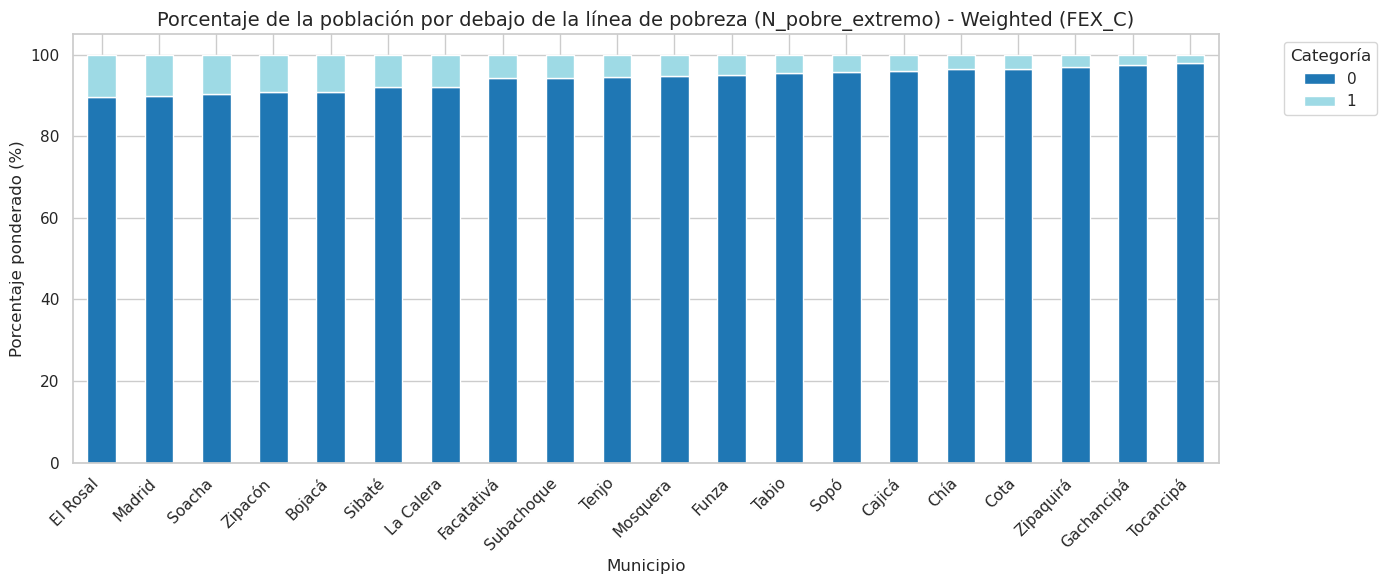

Porcentaje de viviendas con pobreza multidimensional
1: 'Si'
0: 'No'


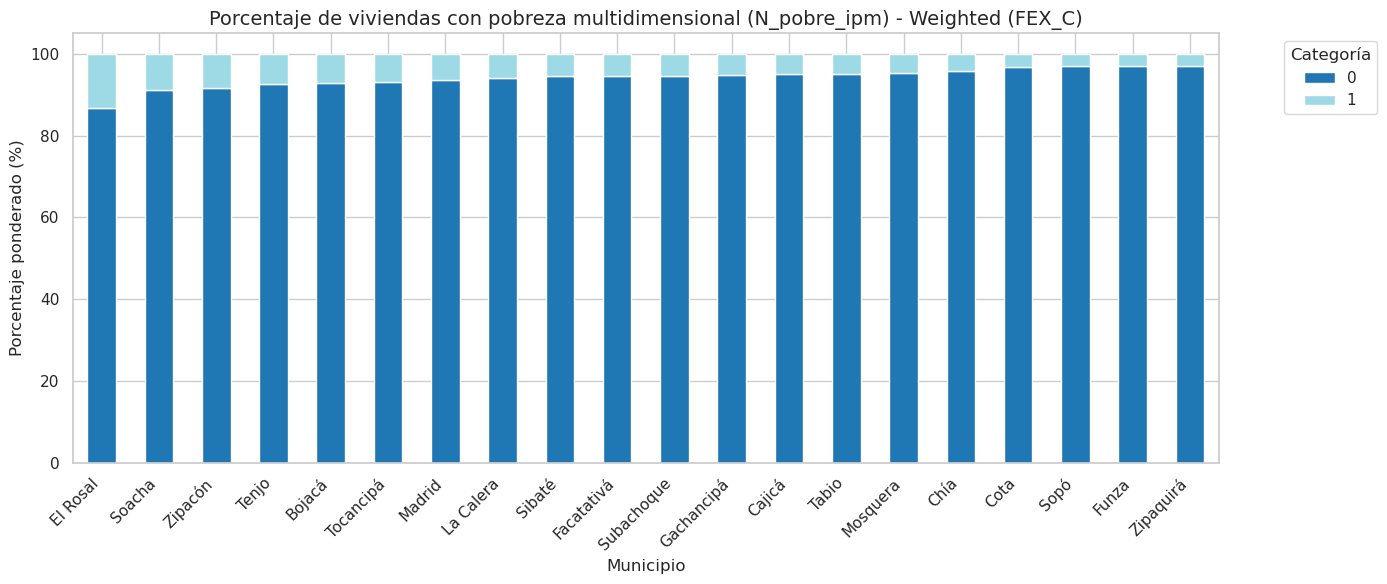

Ocupados informales
1: 'Informal'
0: 'Formal'


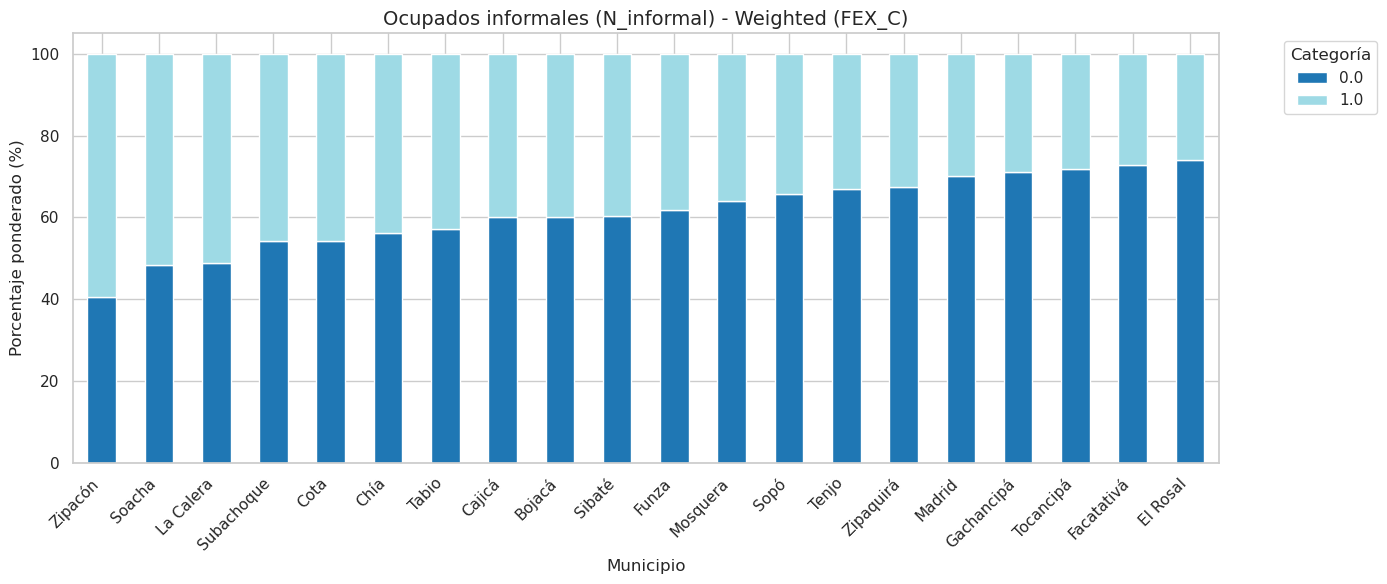

Porcentaje de unidades de vivienda en condiciones inferiores a los estándares de habitabilidad
1: 'Si'
0: 'No'


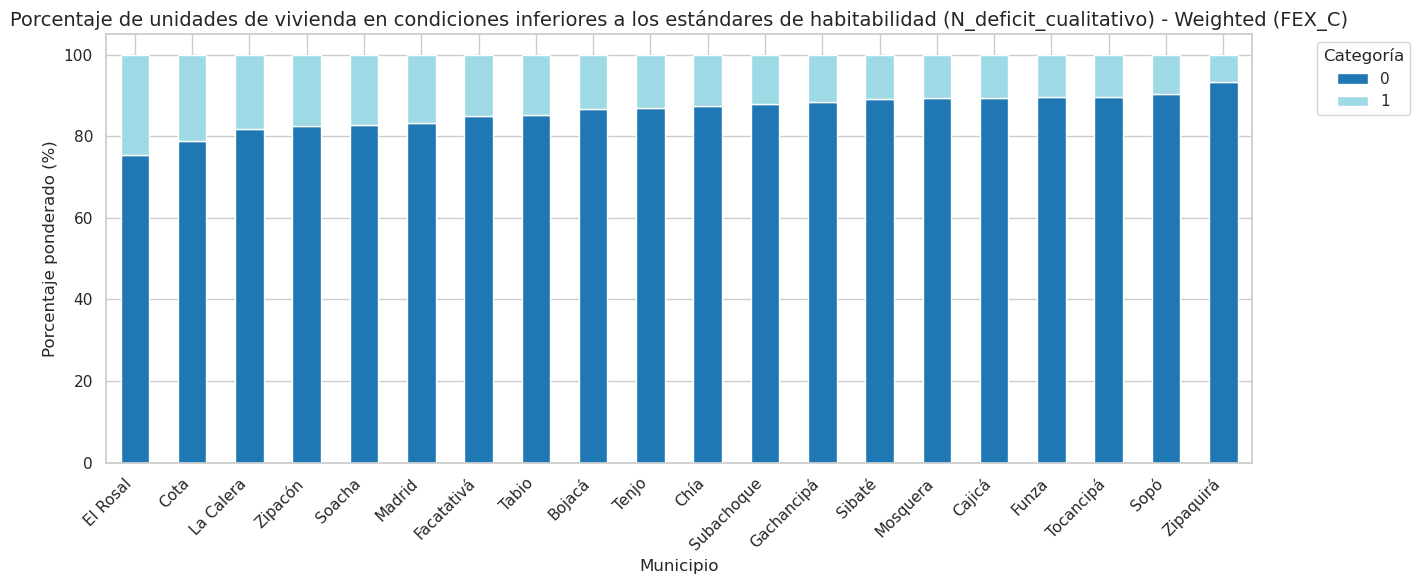

Porcentaje de cantidad de hogares en déficit cuantitativo
1: 'Si'
0: 'No'


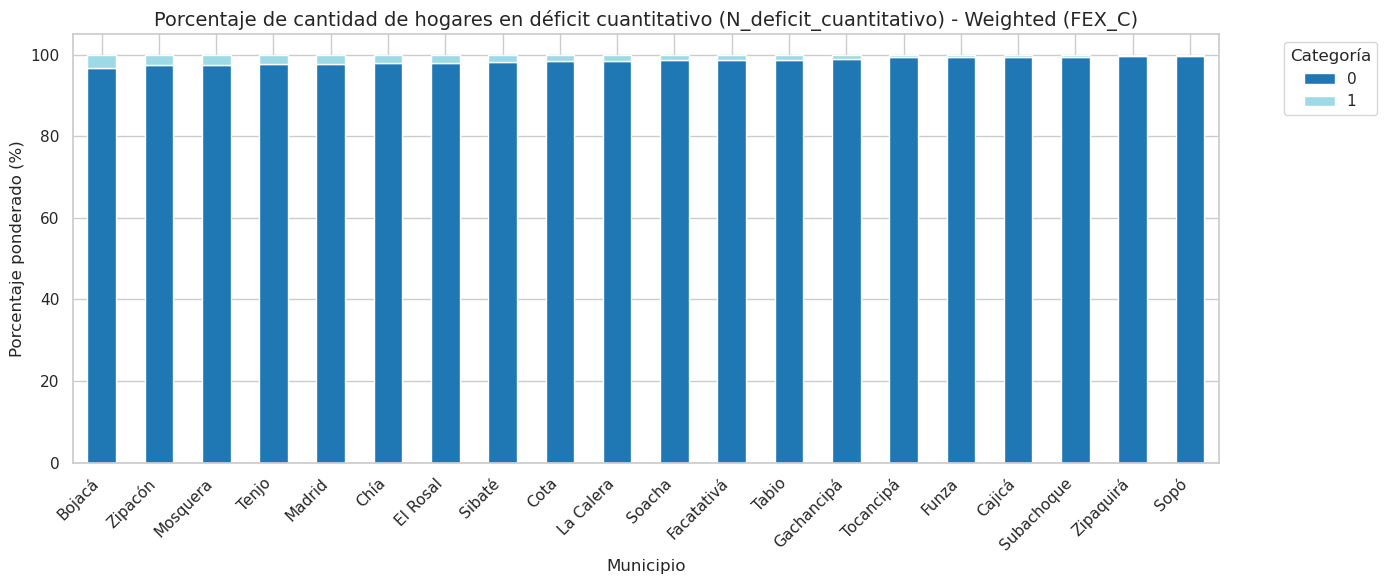

In [32]:
for var, title in raw_vars.items():
    plot_stacked_bars_raw_weighted(additional_df, var, title)

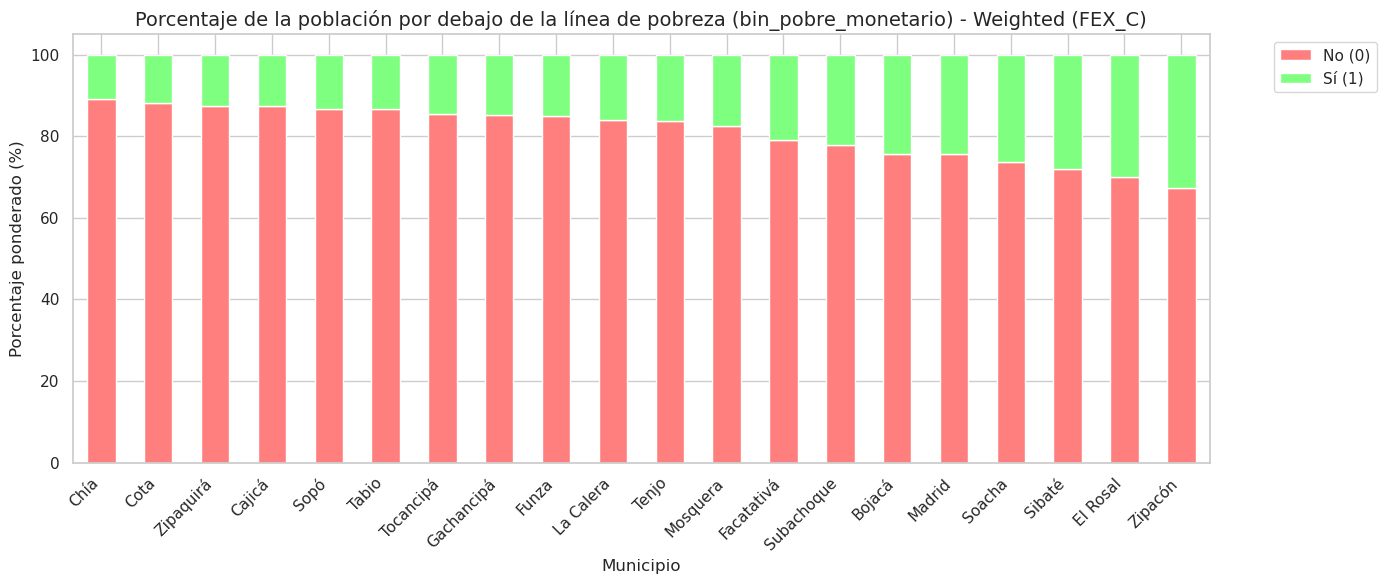

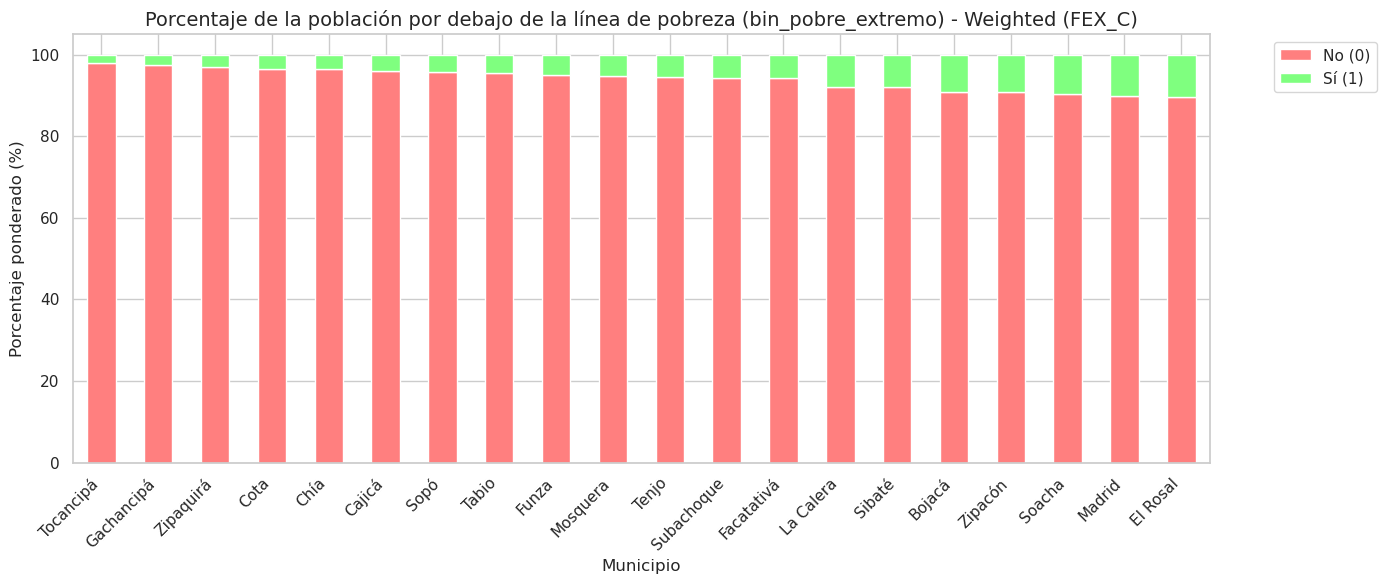

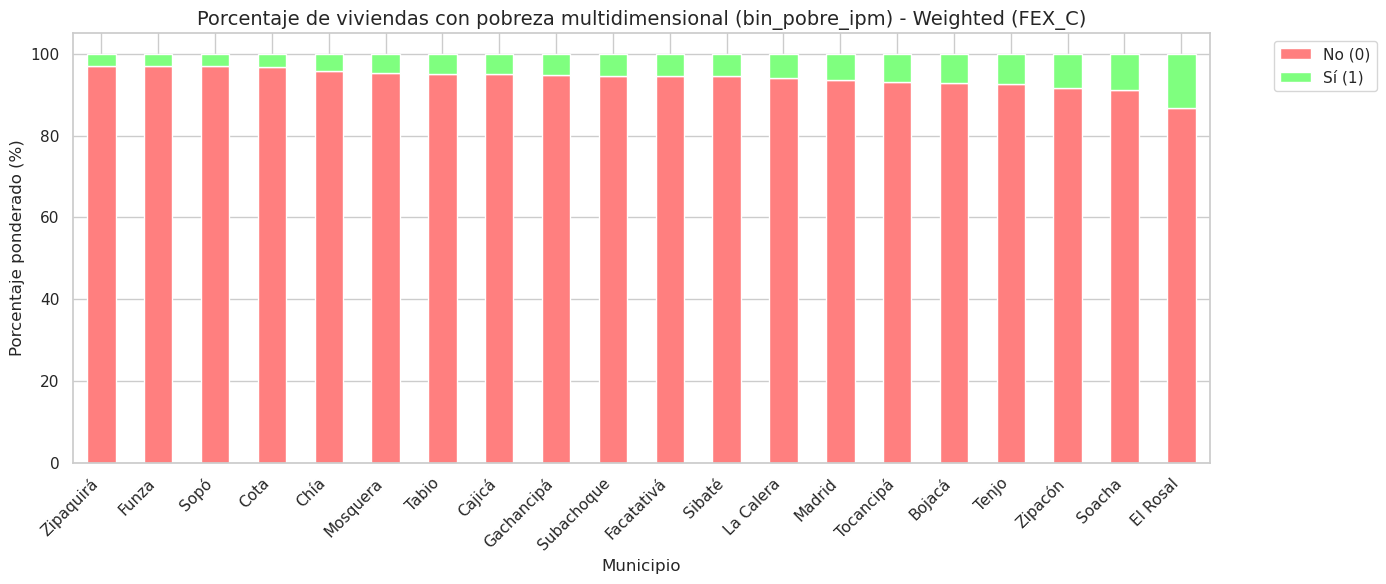

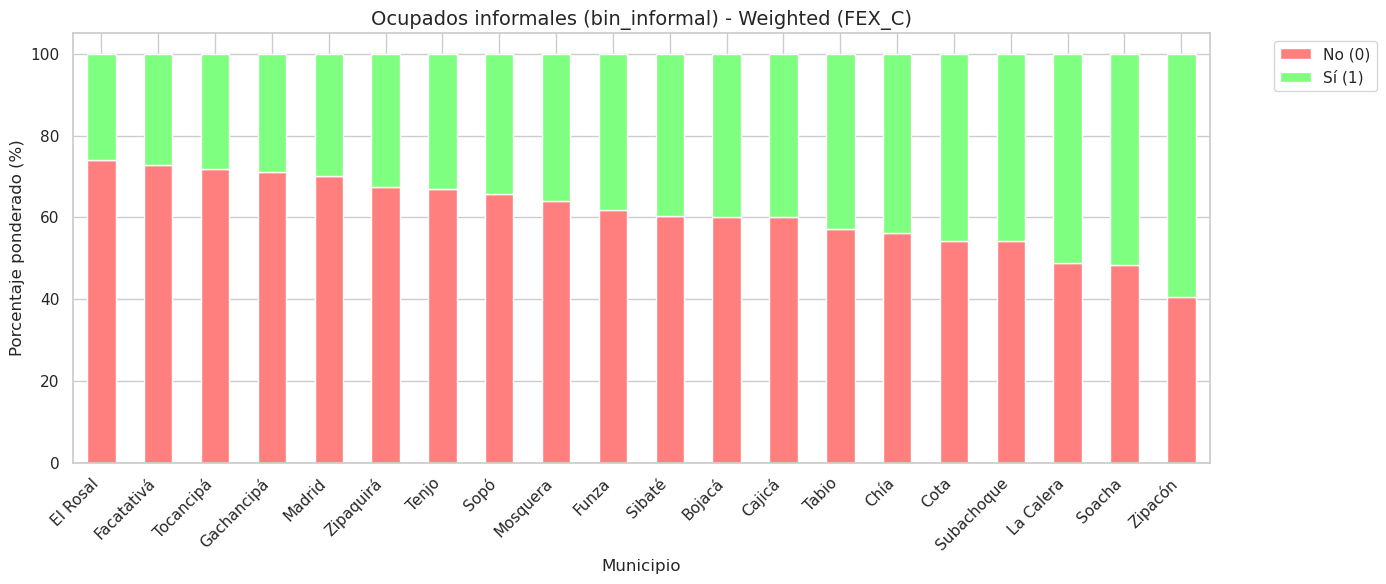

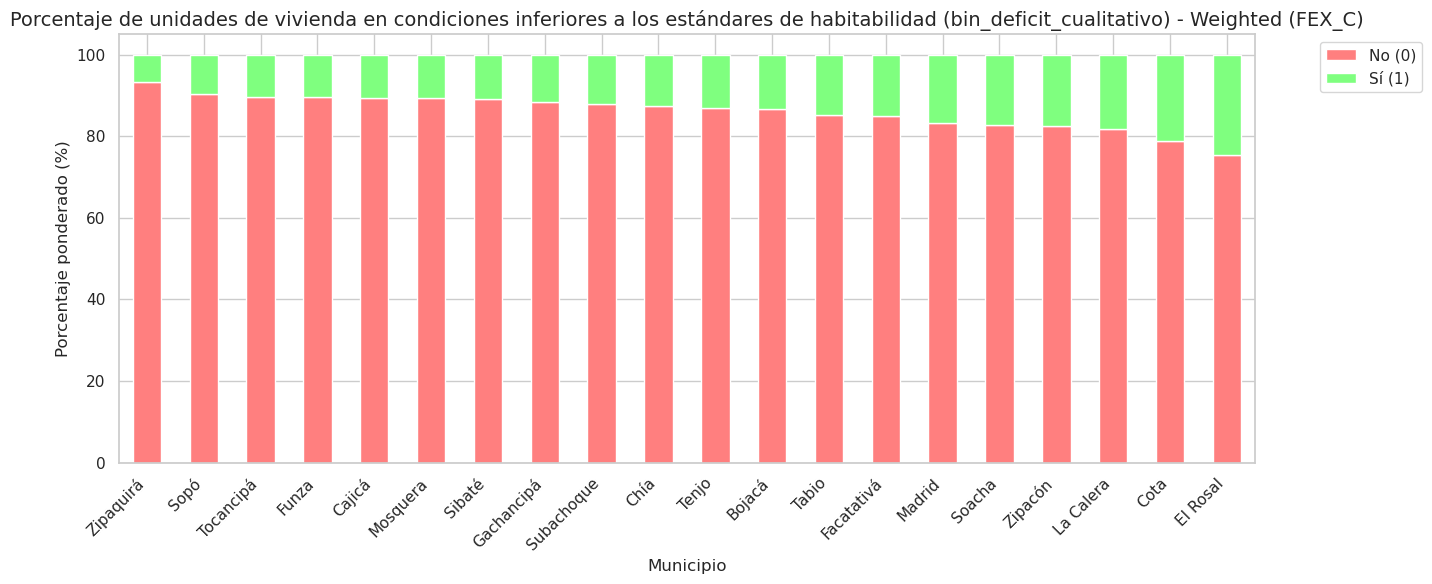

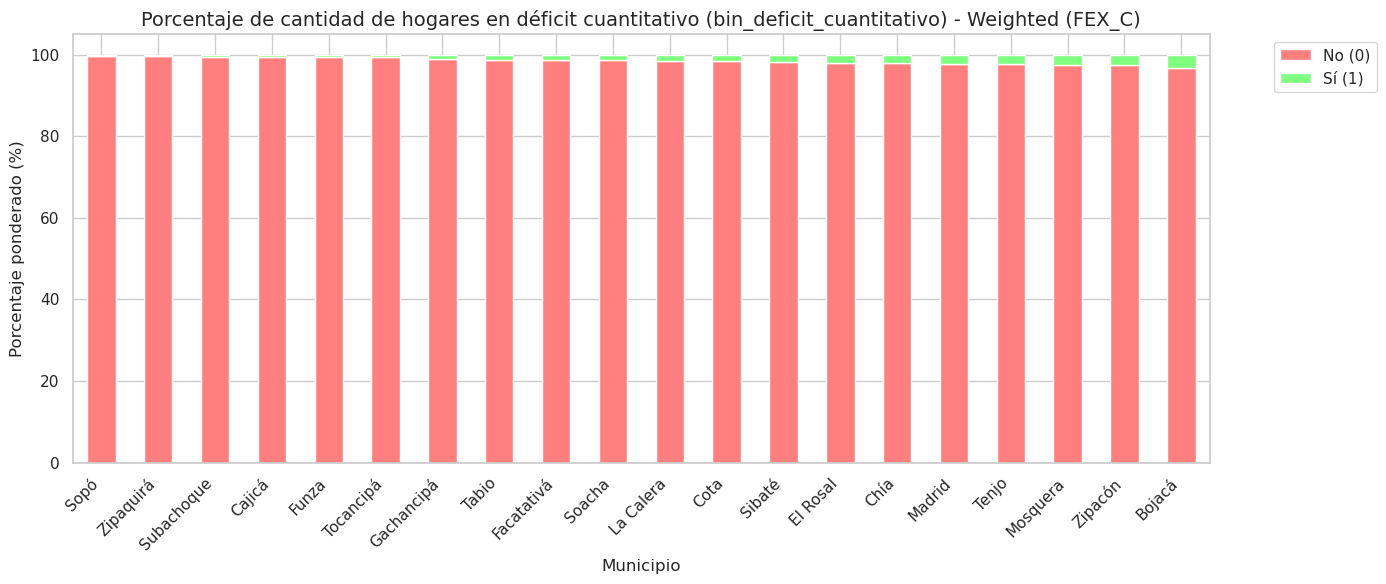

In [33]:
# Reuse households_bin (already filtered to the 21 municipalities)
df_vars_add = {}
for var, title in binary_vars.items():
    df_vars_add[var] = plot_stacked_bars_bin_weighted(additional_df, var, title)

In [34]:
df_adds = municipios_order_df.copy()
for var in df_vars_add.keys():
    var_df = pd.DataFrame(df_vars_add[var][1.0]/100).reset_index()
    var_df.columns = ['municipio', var]
    df_adds = df_adds.merge(var_df, on='municipio')

df_adds

,municipio,bin_pobre_monetario,bin_pobre_extremo,bin_pobre_ipm,bin_informal,bin_deficit_cualitativo,bin_deficit_cuantitativo
0,El Rosal,0.299748,0.104835,0.131679,0.260540,0.245161,0.019770
1,Facatativá,0.208148,0.058150,0.053698,0.270923,0.150904,0.012110
2,Subachoque,0.222171,0.056784,0.053494,0.458756,0.120493,0.005523
3,Bojacá,0.243317,0.090318,0.071403,0.398463,0.133691,0.033693
4,Funza,0.150060,0.048591,0.029507,0.381638,0.103247,0.006487
5,Madrid,0.244514,0.102392,0.064245,0.300057,0.168297,0.022295
6,Mosquera,0.174510,0.053039,0.047523,0.359463,0.105942,0.024954
7,Zipacón,0.327040,0.091127,0.084807,0.593938,0.175518,0.025620
8,Gachancipá,0.148327,0.025678,0.051072,0.288779,0.115797,0.011622
9,Tocancipá,0.144454,0.020737,0.069237,0.282124,0.102856,0.006651


In [35]:
save_path = EXPORT_DIR / 'VARIABLES_ADICIONALES_2021.csv'
export_excel(df_adds, save_path)

succesfully saved, check export folder


## Statistics general BioMap

In [36]:
SOIL_PATH = DATA_DIR / 'Statistics-for-Website-MB-Cobertura-col3.xlsx'

In [37]:
soil = pd.read_excel(SOIL_PATH, sheet_name='COBERTURA_MUNICIPIO')
soil = soil[soil['departamento'].astype(str).str.strip().str.lower() == 'cundinamarca'].copy()
soil.head()

,municipio,departamento,pais,class_level_0,class_level_1,class_level_2,1985,1986,1987,1988,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
4492,Agua De Dios,Cundinamarca,Colombia,Antrópico,3. Área agropecuaria,3.4. Mosaico de agricultura o pasto,6986.125572,6984.431997,6974.804413,6944.673868,...,6800.615495,6759.965910,6761.391838,6783.767083,6826.467699,6796.693302,6784.748205,6775.833715,6733.846549,6712.362906
4493,Agua De Dios,Cundinamarca,Colombia,Antrópico,4. Área sin vegetación,4.2. Infraestructura urbana,20.413926,32.715782,37.262119,42.521617,...,67.838433,68.640732,69.621311,70.869324,72.295626,75.059066,76.217935,76.217935,76.574510,77.644241
4494,Agua De Dios,Cundinamarca,Colombia,Antrópico,4. Área sin vegetación,4.3. Minería,NaN,NaN,NaN,NaN,...,9.806026,9.271152,9.806029,9.627738,9.806030,9.806029,8.557987,8.290549,7.933966,6.507634
4495,Agua De Dios,Cundinamarca,Colombia,Antrópico,4. Área sin vegetación,4.5. Otra área sin vegetación,71.315001,58.834852,51.435889,47.691821,...,27.188703,25.316679,24.870945,23.088081,23.801235,23.355526,22.998938,22.642380,22.642372,21.929232
4496,Agua De Dios,Cundinamarca,Colombia,Natural,1. Formacion Boscosa,1.1. Bosque,1324.870660,1322.552874,1335.835847,1372.474058,...,1470.622139,1516.709797,1528.922664,1522.771784,1474.543986,1467.412106,1475.791321,1483.101590,1530.794587,1575.990676


### Area percentual

In [38]:
area_df = pd.DataFrame(soil['municipio'].unique(), columns=['municipio'])

for sel_year in [2011, 2014, 2017, 2021]:

    soil_long = soil[['municipio', 'departamento', 'class_level_0', 'class_level_1', 'class_level_2', sel_year]].copy()
    soil_long.columns = ['municipio', 'departamento', 'class_level_0', 'class_level_1', 'class_level_2', f'area_ha_{sel_year}']
    soil_long[f'area_ha_{sel_year}'] = pd.to_numeric(soil_long[f'area_ha_{sel_year}'], errors='coerce').fillna(0)
    soil_long['municipio'] = soil_long['municipio'].astype(str).apply(normalize_municipality)
    soil_long['municipio'] = soil_long['municipio'].map(lambda x: manual_mapping.get(x, x))

    level0 = soil_long.groupby(['municipio', 'class_level_0'])[f'area_ha_{sel_year}'].sum().reset_index()
    level0['share'] = level0.groupby('municipio')[f'area_ha_{sel_year}'].transform(lambda s: s / s.sum())
    level0_wide = level0.pivot(index='municipio', columns='class_level_0', values='share').reset_index()
    level0_wide = level0_wide.rename(columns={'Antrópico': f'share_anthropic_{sel_year}', 'Natural': f'share_natural_{sel_year}'})

    level1 = soil_long.groupby(['municipio', 'class_level_1'])[f'area_ha_{sel_year}'].sum().reset_index()
    level1['share'] = level1.groupby('municipio')[f'area_ha_{sel_year}'].transform(lambda s: s / s.sum())
    level1_wide = level1.pivot(index='municipio', columns='class_level_1', values='share').reset_index()
    level1_wide = level1_wide.rename(columns={
        '1. Formacion Boscosa': f'share_forest_{sel_year}',
        '2. Formación natural no boscosa': f'share_natural_non_forest_{sel_year}',
        '3. Área  agropecuaria': f'share_agriculture_{sel_year}',
        '4. Área sin vegetación': f'share_no_vegetation_{sel_year}',
        '5. Cuerpo de agua': f'share_water_{sel_year}',
    })

    selected_classes = {
        f'share_urban_infrastructure_{sel_year}': '4.2. Infraestructura urbana',
        f'share_agriculture_pasture_mosaic_{sel_year}': '3.4. Mosaico de agricultura o pasto',
        f'share_forest_level2_{sel_year}': '1.1. Bosque',
        f'share_mining_{sel_year}': '4.3. Minería',
        f'share_other_no_vegetation_{sel_year}': '4.5. Otra área sin vegetación',
        f'share_herbazales_arbustales_{sel_year}': '2.7. Herbazales o arbustales andinos',
    }
    level2 = soil_long.groupby(['municipio', 'class_level_2'])[f'area_ha_{sel_year}'].sum().reset_index()
    level2['share'] = level2.groupby('municipio')[f'area_ha_{sel_year}'].transform(lambda s: s / s.sum())
    level2_wide = level2.pivot(index='municipio', columns='class_level_2', values='share').reset_index()
    level2_features = {feat: level2_wide[cls].fillna(0) for feat, cls in selected_classes.items()}
    level2_feature_df = pd.DataFrame(level2_features)
    level2_feature_df['municipio'] = level2_wide['municipio']

    soil_features = level0_wide.merge(level1_wide, on='municipio', how='outer').merge(level2_feature_df, on='municipio', how='outer')
    soil_features['area_total_ha_' + str(sel_year)] = soil_long.groupby('municipio')[f'area_ha_{sel_year}'].sum().reindex(soil_features['municipio']).values

    area_df = area_df.merge(soil_features, on='municipio', how='left')

### Area absolute

In [39]:
# Create absolute-area versions of the share-based soil features
for sel_year in [2011, 2014, 2017, 2021]:
    soil_long = soil[['municipio', 'departamento', 'class_level_0', 'class_level_1', 'class_level_2', sel_year]].copy()
    soil_long.columns = ['municipio', 'departamento', 'class_level_0', 'class_level_1', 'class_level_2', f'area_ha_{sel_year}']
    soil_long[f'area_ha_{sel_year}'] = pd.to_numeric(soil_long[f'area_ha_{sel_year}'], errors='coerce').fillna(0)

    soil_long['municipio'] = soil_long['municipio'].astype(str).apply(normalize_municipality)
    soil_long['municipio'] = soil_long['municipio'].map(lambda x: manual_mapping.get(x, x))

    # Level 0: total areas by class
    level0 = soil_long.groupby(['municipio', 'class_level_0'])[f'area_ha_{sel_year}'].sum().reset_index()
    level0['total'] = level0[f'area_ha_{sel_year}']
    level0_wide = level0.pivot(index='municipio', columns='class_level_0', values='total').reset_index()
    level0_wide = level0_wide.rename(columns={
        'Antrópico': f'total_anthropic_{sel_year}',
        'Natural': f'total_natural_{sel_year}',
    })

    # Level 1: total areas by class
    level1 = soil_long.groupby(['municipio', 'class_level_1'])[f'area_ha_{sel_year}'].sum().reset_index()
    level1['total'] = level1[f'area_ha_{sel_year}']
    level1_wide = level1.pivot(index='municipio', columns='class_level_1', values='total').reset_index()
    level1_wide = level1_wide.rename(columns={
        '1. Formacion Boscosa': f'total_forest_{sel_year}',
        '2. Formación natural no boscosa': f'total_natural_non_forest_{sel_year}',
        '3. Área  agropecuaria': f'total_agriculture_{sel_year}',
        '4. Área sin vegetación': f'total_no_vegetation_{sel_year}',
        '5. Cuerpo de agua': f'total_water_{sel_year}',
    })

    # Level 2: selected classes, absolute areas
    selected_classes = {
        f'total_urban_infrastructure_{sel_year}': '4.2. Infraestructura urbana',
        f'total_agriculture_pasture_mosaic_{sel_year}': '3.4. Mosaico de agricultura o pasto',
        f'total_forest_level2_{sel_year}': '1.1. Bosque',
        f'total_mining_{sel_year}': '4.3. Minería',
        f'total_other_no_vegetation_{sel_year}': '4.5. Otra área sin vegetación',
        f'total_herbazales_arbustales_{sel_year}': '2.7. Herbazales o arbustales andinos',
    }
    level2 = soil_long.groupby(['municipio', 'class_level_2'])[f'area_ha_{sel_year}'].sum().reset_index()
    level2['total'] = level2[f'area_ha_{sel_year}']
    level2_wide = level2.pivot(index='municipio', columns='class_level_2', values='total').reset_index()
    level2_features = {feat: level2_wide[cls].fillna(0) for feat, cls in selected_classes.items()}
    level2_feature_df = pd.DataFrame(level2_features)
    level2_feature_df['municipio'] = level2_wide['municipio']

    soil_features_total = (
        level0_wide.merge(level1_wide, on='municipio', how='outer')
        .merge(level2_feature_df, on='municipio', how='outer')
    )

    for col in soil_features_total.columns:
        if col != 'municipio' and col in area_df.columns:
            area_df.drop(columns=[col], inplace=True)

    area_df = area_df.merge(soil_features_total, on='municipio', how='left')

area_df.head()

,municipio,share_anthropic_2011,share_natural_2011,share_forest_2011,share_natural_non_forest_2011,share_agriculture_2011,share_no_vegetation_2011,share_water_2011,share_urban_infrastructure_2011,share_agriculture_pasture_mosaic_2011,...,total_natural_non_forest_2021,total_agriculture_2021,total_no_vegetation_2021,total_water_2021,total_urban_infrastructure_2021,total_agriculture_pasture_mosaic_2021,total_forest_level2_2021,total_mining_2021,total_other_no_vegetation_2021,total_herbazales_arbustales_2021
0,Agua De Dios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Albán,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Anapoima,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Anolaima,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Apulo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# select columns 2021
select_cols_2021 = [col for col in area_df.columns if ('_2021' in col and 'total' in col) or col == 'municipio']

area_df[area_df['municipio'].isin(municipios_20)][select_cols_2021]

,municipio,area_total_ha_2021,total_anthropic_2021,total_natural_2021,total_forest_2021,total_natural_non_forest_2021,total_agriculture_2021,total_no_vegetation_2021,total_water_2021,total_urban_infrastructure_2021,total_agriculture_pasture_mosaic_2021,total_forest_level2_2021,total_mining_2021,total_other_no_vegetation_2021,total_herbazales_arbustales_2021
8,Bojacá,10243.435313,7062.575772,3180.859541,1592.604647,1579.255696,6543.083890,519.491882,8.999197,112.176719,5688.797753,1592.604647,139.814521,267.500642,0.000000
11,Cajicá,5106.787314,4663.294918,443.492396,363.771796,60.747704,3485.525902,1177.769017,18.972896,837.586622,3125.847686,363.771796,32.600952,307.581443,1.336067
18,Chía,8007.127127,6238.715466,1768.411661,1453.682113,302.346848,4621.220265,1617.495202,12.382700,1221.786880,4493.387902,1453.682113,43.025925,352.682397,49.888389
20,Cota,5336.894291,4142.706341,1194.187951,887.708140,296.055114,3057.967143,1084.739198,10.424697,822.803510,2972.531145,887.708140,0.000000,261.935688,48.554224
25,El Rosal,8692.095318,8059.454981,632.640337,573.933525,0.000000,7394.698498,664.756484,58.706812,540.304221,7394.698498,573.933525,11.937422,112.514841,0.000000
26,Facatativá,15797.072393,12790.940821,3006.131571,2472.289649,507.025537,11537.875088,1253.065734,26.816385,970.827148,11191.045248,2472.289649,0.000000,282.238585,7.305368
28,Funza,6987.004788,6787.238160,199.766628,14.968824,130.357479,5255.603434,1531.634725,54.440325,1310.844134,5255.603434,14.968824,0.000000,220.790591,0.000000
33,Gachancipá,4292.042558,3397.735063,894.307495,761.777636,130.125049,3126.351534,271.383529,2.404810,198.705608,3035.597895,761.777636,0.000000,72.677921,77.130250
48,La Calera,32606.633919,19019.398102,13587.235817,10943.977598,2316.870688,18691.234922,328.163180,326.387530,104.337972,18474.526445,10943.977598,25.572250,198.252958,2126.903459
55,Madrid,12083.432712,11037.837831,1045.594881,676.007038,317.110092,8901.820473,2136.017358,52.477752,1800.656543,8569.504070,676.007038,50.514189,284.846627,0.000000


In [41]:
show_area = area_df[area_df['municipio'].isin(municipios_20)][['municipio', 'area_total_ha_2021', 'total_urban_infrastructure_2021']]
show_area['area_total_km2_2021'] = show_area['area_total_ha_2021']/100
show_area['area_total_km2_urban_infrastructure_2021'] = show_area['total_urban_infrastructure_2021']/100

In [42]:
municipios_order_df.merge(show_area, on='municipio')

,municipio,area_total_ha_2021,total_urban_infrastructure_2021,area_total_km2_2021,area_total_km2_urban_infrastructure_2021
0,El Rosal,8692.095318,540.304221,86.920953,5.403042
1,Facatativá,15797.072393,970.827148,157.970724,9.708271
2,Subachoque,20878.502083,43.112161,208.785021,0.431122
3,Bojacá,10243.435313,112.176719,102.434353,1.121767
4,Funza,6987.004788,1310.844134,69.870048,13.108441
5,Madrid,12083.432712,1800.656543,120.834327,18.006565
6,Mosquera,10514.950852,884.712789,105.149509,8.847128
7,Zipacón,5398.361499,8.909911,53.983615,0.089099
8,Gachancipá,4292.042558,198.705608,42.920426,1.987056
9,Tocancipá,7356.416391,829.511725,73.564164,8.295117


In [43]:
save_path = EXPORT_DIR / 'AREA_2021.csv'
export_excel(municipios_order_df.merge(show_area, on='municipio'), save_path)

succesfully saved, check export folder


### WEI

In [44]:
# Calcular WEI para todos los años y municipios
classes_level1 = ['total_forest', 'total_natural_non_forest', 'total_agriculture', 'total_no_vegetation', 'total_water']
wei_weights = {
    'total_forest': 0.3,
    'total_natural_non_forest': 0.25,
    'total_agriculture': 0.15,
    'total_no_vegetation': 0.0,
    'total_water': 0.3,
}

for yr in [2011, 2014, 2017, 2021]:
    total_col = f'area_total_ha_{yr}'
    # ensure component columns exist
    comp_cols = {cls: f'{cls}_{yr}' for cls in classes_level1}
    for col in comp_cols.values():
        if col not in area_df.columns:
            area_df[col] = 0.0
    # compute weighted sum
    weighted_sum = sum(area_df[comp_cols[cls]] * wei_weights[cls] for cls in classes_level1)
    # compute WEI for year (0 if total_area is zero or missing)
    area_df[f'WEI_{yr}'] = np.where(area_df[total_col] > 0, weighted_sum / area_df[total_col], 0.0)

In [45]:
select_cols = [col for col in area_df.columns if ('WEI' in col) or col == 'municipio']
show_wei = area_df[area_df['municipio'].isin(municipios_20)][select_cols]

In [46]:
municipios_order_df.merge(show_wei, on='municipio')

,municipio,WEI_2011,WEI_2014,WEI_2017,WEI_2021
0,El Rosal,0.147701,0.148760,0.149257,0.149446
1,Facatativá,0.164553,0.164514,0.164668,0.165041
2,Subachoque,0.179953,0.180099,0.180489,0.180235
3,Bojacá,0.185700,0.185336,0.184737,0.181263
4,Funza,0.132203,0.127659,0.124546,0.120474
5,Madrid,0.140669,0.139419,0.138395,0.135152
6,Mosquera,0.148843,0.142972,0.139072,0.137008
7,Zipacón,0.191988,0.190786,0.193189,0.192448
8,Gachancipá,0.176495,0.174879,0.172982,0.170254
9,Tocancipá,0.163110,0.158987,0.156025,0.154759


In [47]:
save_path = EXPORT_DIR / 'WEI_2021.csv'
export_excel(municipios_order_df.merge(show_wei, on='municipio'), save_path)


succesfully saved, check export folder


### Tasa Crecimiento anual

In [48]:
cagr_mapping = {
    2014: (2011, 3),
    2017: (2014, 3),
    2021: (2017, 4),
}

for year, (start_year, n_years) in cagr_mapping.items():
    start_col = f'total_urban_infrastructure_{start_year}'
    end_col = f'total_urban_infrastructure_{year}'
    cagr_col = f'total_urban_infrastructure_CAGR_{year}'
    if start_col in area_df.columns and end_col in area_df.columns:
        area_df[cagr_col] = np.where(
            (area_df[start_col] > 0) & (area_df[end_col] > 0),
            (area_df[end_col] / area_df[start_col]) ** (1 / n_years) - 1,
            np.nan
        )
    else:
        area_df[cagr_col] = np.nan

    area_df[cagr_col] = area_df[cagr_col] * 100  # Convert to percentage

In [49]:
select_cols = [col for col in area_df.columns if ('CAGR' in col) or col == 'municipio']
show_cagr = area_df[area_df['municipio'].isin(municipios_20)][select_cols]

In [50]:
municipios_order_df.merge(show_cagr, on='municipio')

,municipio,total_urban_infrastructure_CAGR_2014,total_urban_infrastructure_CAGR_2017,total_urban_infrastructure_CAGR_2021
0,El Rosal,1.069831,0.959405,1.715840
1,Facatativá,1.815500,2.183171,2.722208
2,Subachoque,2.278028,2.763822,6.095200
3,Bojacá,2.833764,1.322658,5.689990
4,Funza,5.671883,3.269477,2.906431
5,Madrid,2.714085,1.790952,3.340216
6,Mosquera,5.745088,4.351779,3.104726
7,Zipacón,2.041386,4.380446,14.588688
8,Gachancipá,5.006912,7.344894,4.525560
9,Tocancipá,5.234527,4.622890,4.876493


In [51]:
save_path = EXPORT_DIR / 'CAGR_2021.csv'
export_excel(municipios_order_df.merge(show_cagr, on='municipio'), save_path)


succesfully saved, check export folder


In [52]:
df_vars_cagr = {}
for var in ['WEI_2021', 'total_urban_infrastructure_2021', 'total_urban_infrastructure_CAGR_2021']:
    df_vars_cagr[var] = area_df[area_df['municipio'].str.lower().isin(list(map(str.lower, municipios_20)))].sort_values(var)[var]

## Encuesta Multiproposito 2021

In [53]:
# Load raw data
ident = load_semicolon_csv(
    MULTI_DIR / 'Identificación (Capítulo A).csv',
    columns=['DIRECTORIO', 'DPTO', 'MPIO', 'NOMBRE_ESTRATO', 'FEX_C'],
    encodings=('latin1', 'utf-8'),
)
ident['weight'] = parse_weight_series(ident['FEX_C'])
ident_cund = ident[ident['DPTO'] == 25].copy()

households_b = load_semicolon_csv(
    MULTI_DIR / 'Datos de la vivenda y su entorno (Capítulo B).csv',
    columns=['DIRECTORIO', 'NVCBP15D', 'NVCBP15I', 'FEX_C'],
)
households_l = load_semicolon_csv(
    MULTI_DIR / 'Percepción sobre las condiciones de vida y el desempeño institucional (Capítulo L).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCLPA8P', 'NHCLPA7E', 'FEX_C'],
)
for df in [households_b, households_l]:
    df['weight'] = parse_weight_series(df['FEX_C'])
    df.drop(columns=['FEX_C'], inplace=True)

In [54]:
print(households_b.shape, households_l.shape)

(106467, 4) (107119, 5)


In [55]:
base_households = ident_cund[['DIRECTORIO', 'NOMBRE_ESTRATO']].copy()
households_b = households_b.merge(base_households, on='DIRECTORIO', how='inner')
households_l = households_l.merge(base_households, on='DIRECTORIO', how='inner')

households_b = households_b.rename(columns={'weight': 'weight_b'})
households_l = households_l.rename(columns={'weight': 'weight_l'})

households = households_l.merge(households_b,
    on=['DIRECTORIO', 'NOMBRE_ESTRATO'],
    how='left',
)
households['weight'] = households['weight_b'].fillna(households['weight_l'])
households = households.drop(columns=['weight_b', 'weight_l'])

In [56]:
households.describe()

,DIRECTORIO,DIRECTORIO_HOG,NHCLPA7E,NHCLPA8P,NVCBP15D,NVCBP15I,weight
count,2.005800e+04,2.005800e+04,15350.000000,15350.000000,20058.000000,20058.000000,20058.000000
mean,1.071476e+06,1.071476e+07,2.470619,3.561238,1.859956,1.947502,34.739162
std,3.603424e+05,3.603424e+06,1.976872,2.629510,0.347041,0.223034,64.800728
min,3.231660e+05,3.231661e+06,1.000000,1.000000,1.000000,1.000000,1.131677
25%,1.013674e+06,1.013674e+07,2.000000,2.000000,2.000000,2.000000,5.372368
50%,1.051140e+06,1.051141e+07,2.000000,3.000000,2.000000,2.000000,10.716104
75%,1.144072e+06,1.144072e+07,3.000000,3.000000,2.000000,2.000000,45.622283
max,2.193139e+06,2.193139e+07,9.000000,9.000000,2.000000,2.000000,727.016132


In [57]:
# Create binarized variables per summary_dict.md
households['perception_corruption'] = (households['NHCLPA8P'] == 3).astype(float)
households['perception_green_zones'] = (households['NHCLPA7E'] == 3).astype(float)
households['perception_air'] = (households['NVCBP15D'] == 1).astype(float)
households['perception_water'] = (households['NVCBP15I'] == 1).astype(float)

In [58]:
# Get list of 21 municipalities
ident_unique = ident_cund[['NOMBRE_ESTRATO']].drop_duplicates().copy()
ident_unique['municipio_base'] = ident_unique['NOMBRE_ESTRATO'].apply(normalize_municipality)
ident_unique['municipio_base'] = ident_unique['municipio_base'].map(lambda x: manual_mapping.get(x, x))
municipios_20 = ident_unique['municipio_base'].unique()

In [59]:
# Filter to 21 municipalities
households['municipio_base'] = households['NOMBRE_ESTRATO'].apply(normalize_municipality).map(lambda x: manual_mapping.get(x, x))
households = households[households['municipio_base'].isin(municipios_20)].copy()

# Create households_raw from households (already has all raw variables)
households_raw = households.copy()

In [ ]:
# Raw categorical variables from summary_dict.md
raw_vars = {
    'NHCLPA8P': 'Percepción de corrupción',
    'NHCLPA7E': 'Percepción de zonas verdes',
    'NVCBP15D': 'Percepción de calidad del aire',
    'NVCBP15I': 'Percepción de calidad del agua',
}

binary_vars = {
    'perception_corruption': 'Percepción de corrupción (binarizado)',
    'perception_green_zones': 'Percepción de zonas verdes (binarizado)',
    'perception_air': 'Percepción de calidad del aire (binarizado)',
    'perception_water': 'Percepción de calidad del agua (binarizado)',
}

# Detailed categorical values from summary_dict.md
raw_var_questions = {
    'NHCLPA8P': 'Entre el año 2017 y el momento actual ¿cree que el municipio ha mejorado, empeorado o se mantiene igual, en cada uno de los siguientes equipamientos?: 12. En la lucha contra la corrupción en la ciudad',
    'NHCLPA7E': 'Entre el año 2017 y el momento actual ¿cree que el municipio ha mejorado, empeorado o se mantiene igual, en cada uno de los siguientes equipamientos?: 5. Parques y zonas verdes',
    'NVCBP15D': '¿Cuáles de los siguientes problemas presenta el entorno donde está ubicada su vivienda?: 9. Contaminación del aire',
    'NVCBP15I': '¿Cuáles de los siguientes problemas presenta el entorno donde está ubicada su vivienda?: 9. Contaminación de cuerpos de agua (ríos, caños, humedales, lagunas)',
}

# Detailed categorical values from summary_dict.md
raw_var_options = {
    'NHCLPA8P': "1. Mejor\n2. Igual\n3. Peor\n8. No aplica\n9. No sabe",
    'NHCLPA7E': "1. Mejor\n2. Igual\n3. Peor\n8. No aplica\n9. No sabe",
    'NVCBP15D': "1: 'Si'\n2: 'No'",
    'NVCBP15I': "1: 'Si'\n2: 'No'",
}

In [61]:
households[['NHCLPA7E','NHCLPA8P','NVCBP15D','NVCBP15I']].describe()

,NHCLPA7E,NHCLPA8P,NVCBP15D,NVCBP15I
count,15350.000000,15350.000000,20058.000000,20058.000000
mean,2.470619,3.561238,1.859956,1.947502
std,1.976872,2.629510,0.347041,0.223034
min,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000
50%,2.000000,3.000000,2.000000,2.000000
75%,3.000000,3.000000,2.000000,2.000000
max,9.000000,9.000000,2.000000,2.000000


Entre el año 2017 y el momento actual ¿cree que el municipio ha mejorado, empeorado o se mantiene igual, en cada uno de los siguientes equipamientos?: 12. En la lucha contra la corrupción en la ciudad
1. Mejor
2. Igual
3. Peor
8. No aplica
9. No sabe


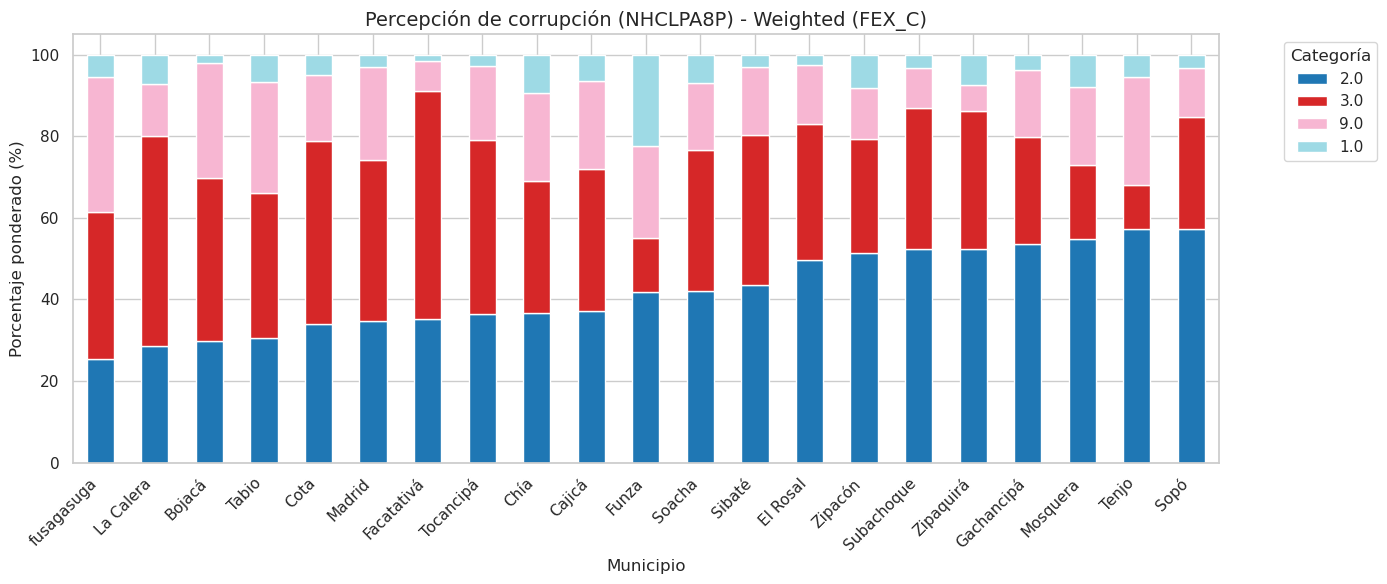

Entre el año 2017 y el momento actual ¿cree que el municipio ha mejorado, empeorado o se mantiene igual, en cada uno de los siguientes equipamientos?: 5. Parques y zonas verdes
1. Mejor
2. Igual
3. Peor
8. No aplica
9. No sabe


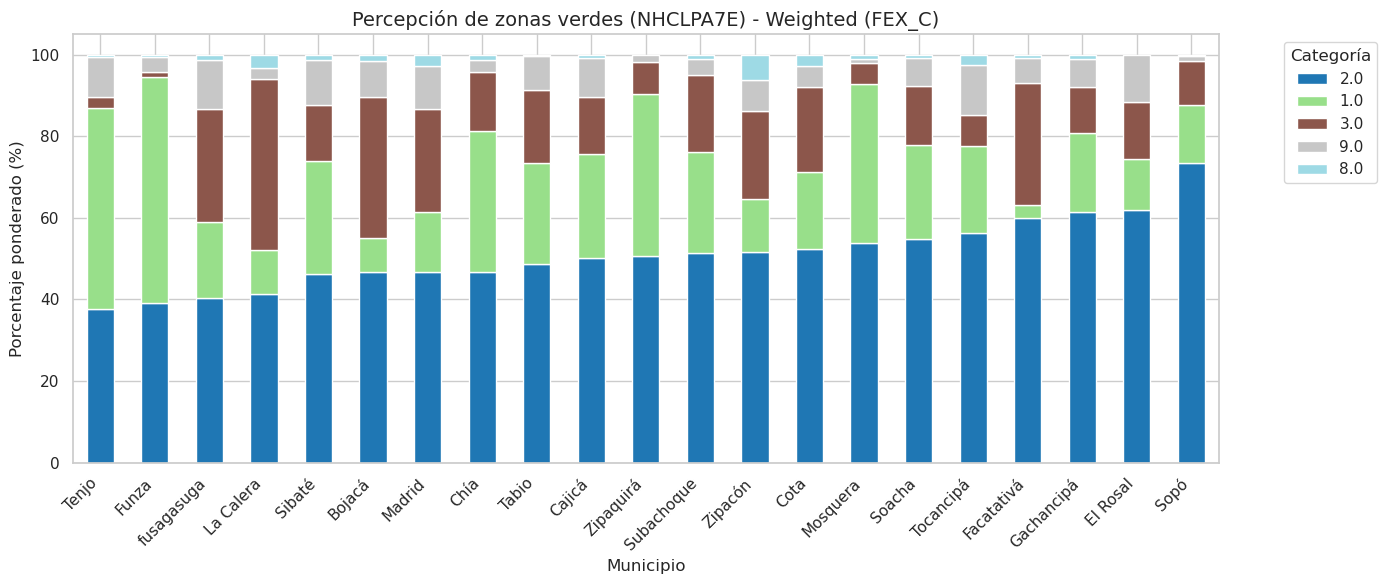

¿Cuáles de los siguientes problemas presenta el entorno donde está ubicada su vivienda?: 9. Contaminación del aire
1: 'Si'
2: 'No'


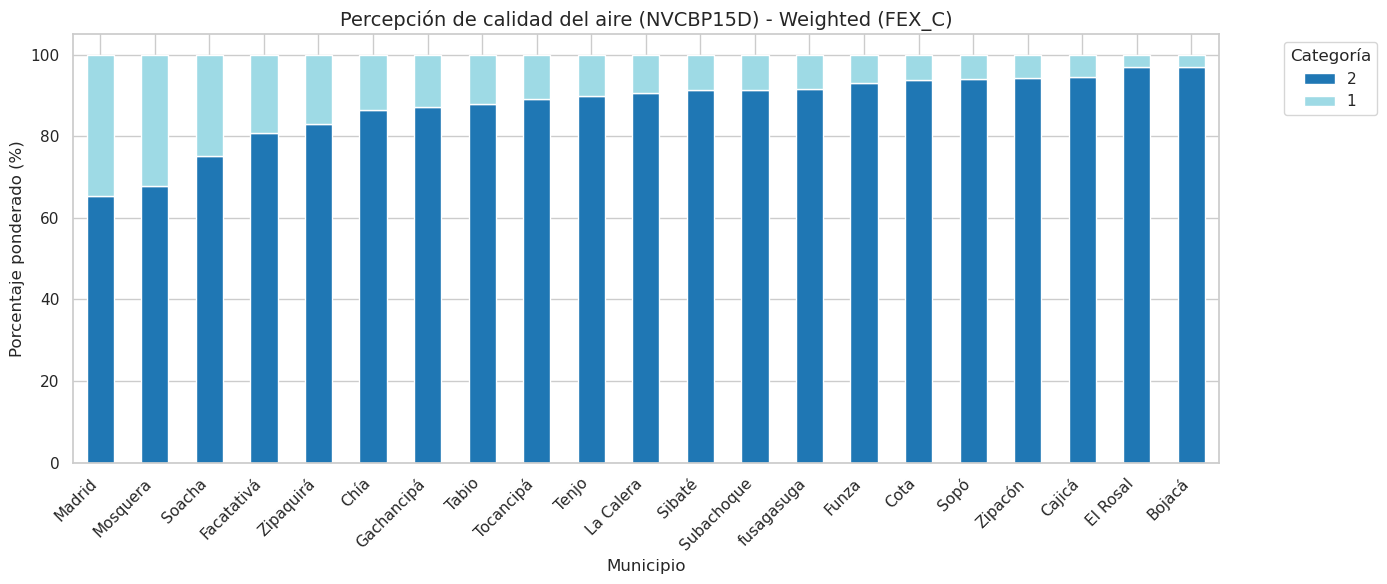

¿Cuáles de los siguientes problemas presenta el entorno donde está ubicada su vivienda?: 9. Contaminación de cuerpos de agua (ríos, caños, humedales, lagunas)
1: 'Si'
2: 'No'


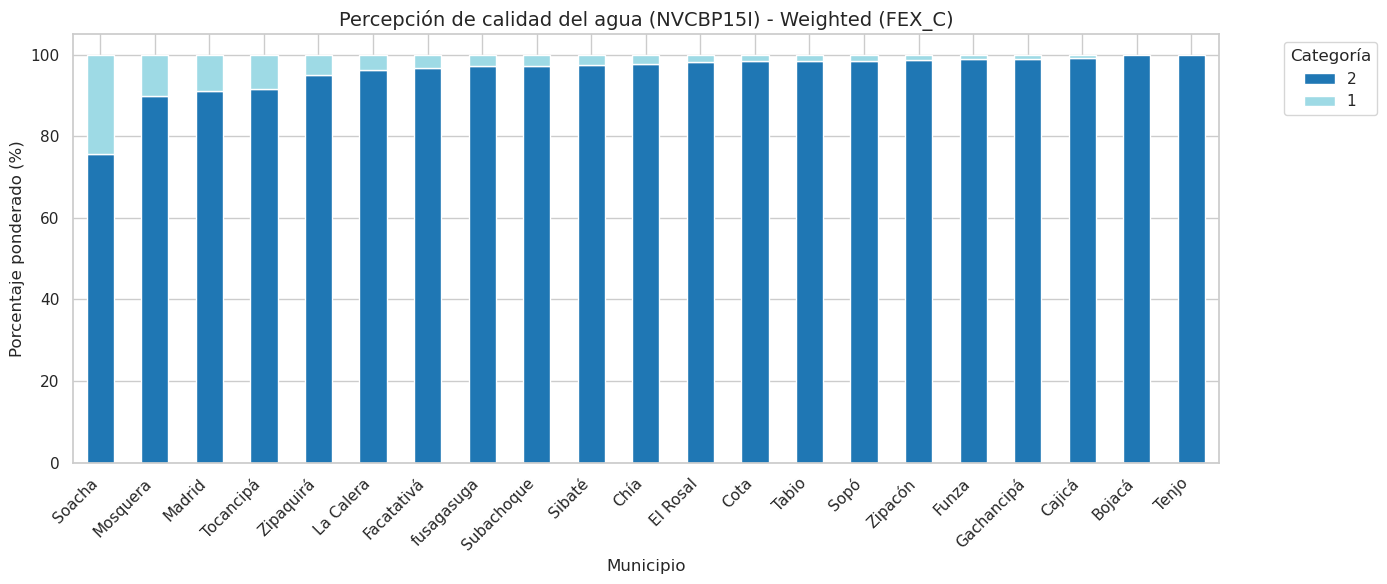

In [62]:
for var, title in raw_vars.items():
    if var in households_raw.columns:
        plot_stacked_bars_raw_weighted(households_raw, var, title)

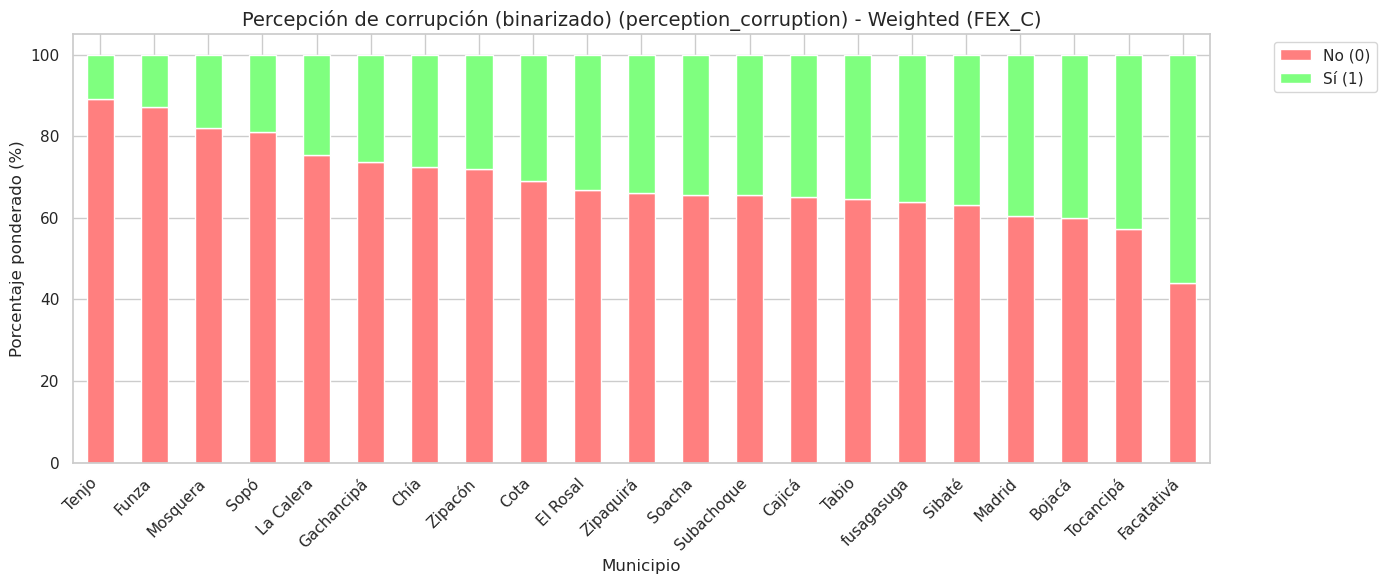

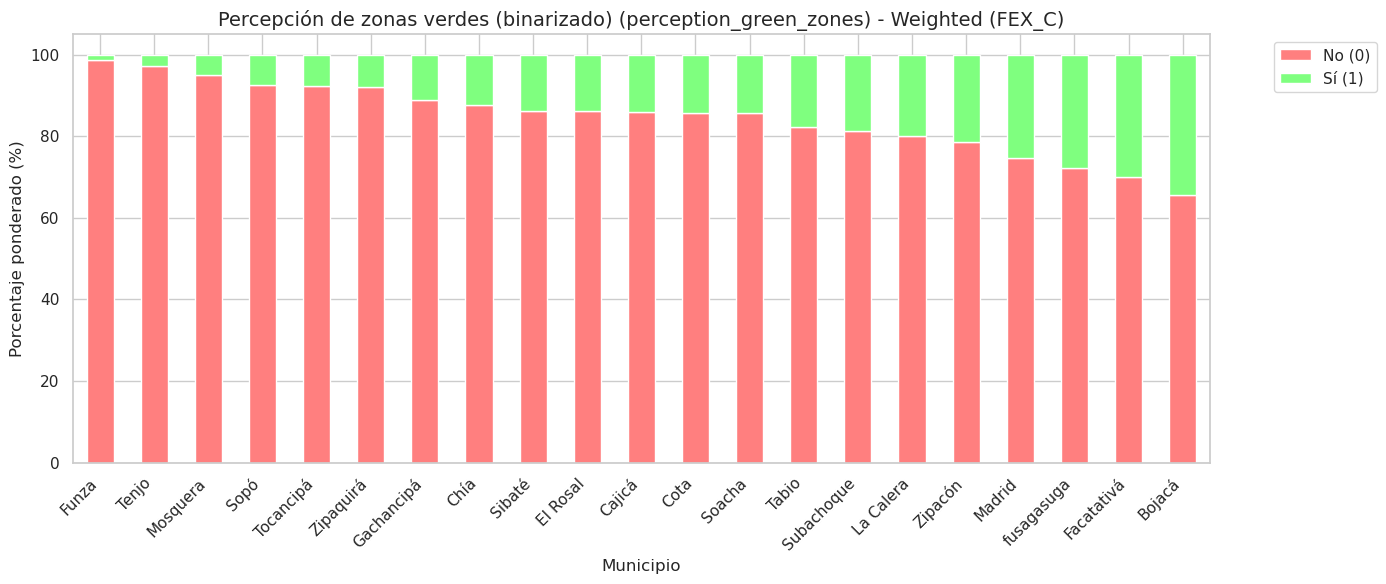

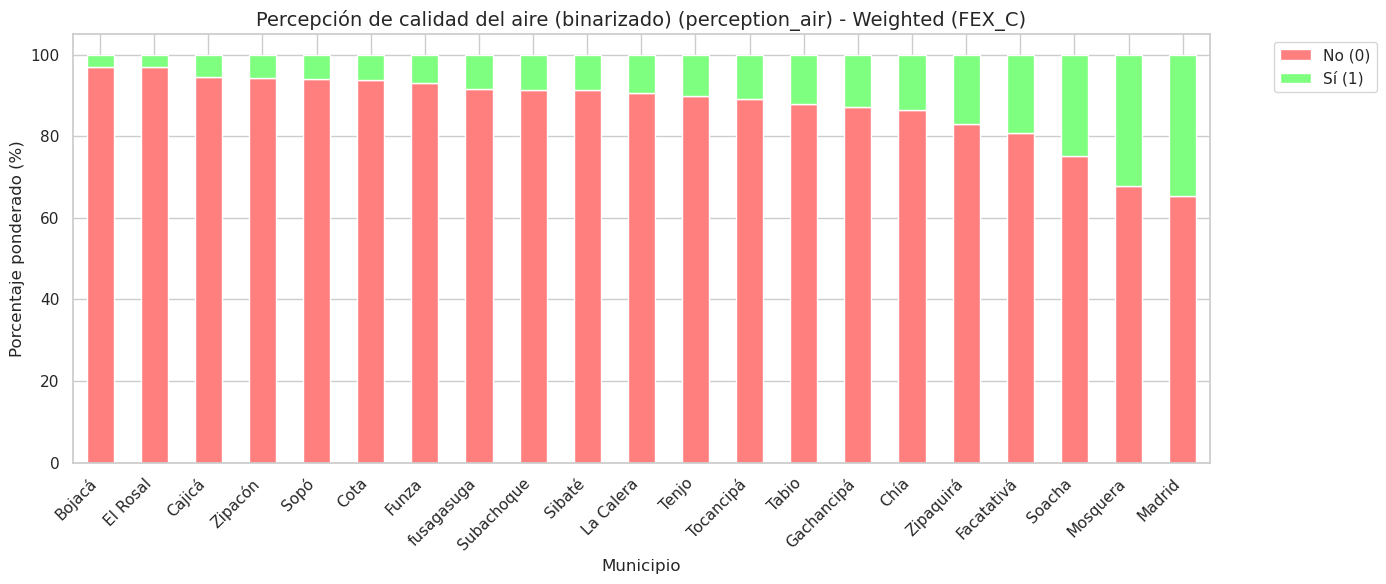

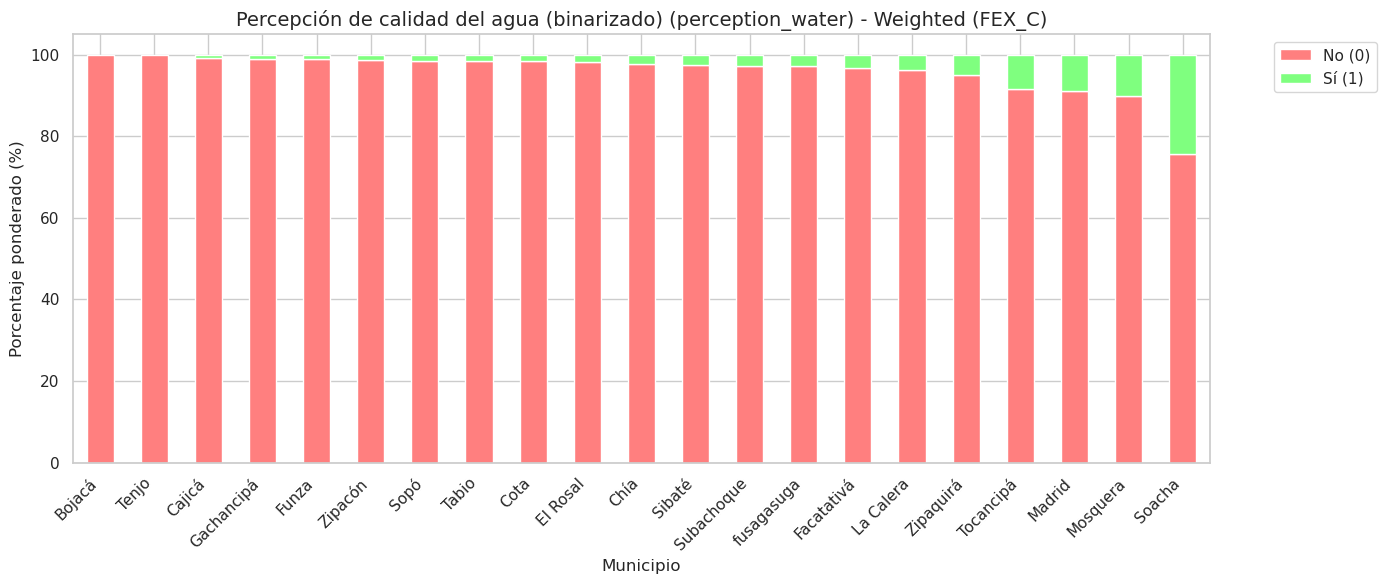

In [63]:
# Reuse households_bin (already filtered to the 21 municipalities)
df_vars_em = {}
for var, title in binary_vars.items():
    df_vars_em[var] = plot_stacked_bars_bin_weighted(households, var, title)

In [64]:
df_em = municipios_order_df.copy()
for var in df_vars_em.keys():
    var_df = pd.DataFrame(df_vars_em[var][1.0]/100).reset_index()
    var_df.columns = ['municipio', var]
    df_em = df_em.merge(var_df, on='municipio')

df_em

,municipio,perception_corruption,perception_green_zones,perception_air,perception_water
0,El Rosal,0.332357,0.138889,0.031272,0.018484
1,Facatativá,0.559794,0.298733,0.190881,0.032514
2,Subachoque,0.345059,0.188011,0.085344,0.026443
3,Bojacá,0.399857,0.343362,0.030258,0.000000
4,Funza,0.128938,0.013096,0.070321,0.011386
5,Madrid,0.395309,0.252198,0.346182,0.088106
6,Mosquera,0.178929,0.050312,0.322335,0.102062
7,Zipacón,0.279644,0.214324,0.058141,0.013495
8,Gachancipá,0.262375,0.111432,0.127299,0.010557
9,Tocancipá,0.427470,0.075500,0.109312,0.084649


In [65]:
save_path = EXPORT_DIR / 'EM_2021.csv'
export_excel(df_em, save_path)

succesfully saved, check export folder


# Export variables